In [1]:
import EOSutils as meos

import numpy as np
import matplotlib.pyplot as plt

import matplotlib.style
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.cm as cmx
from mpl_toolkits.axes_grid1 import make_axes_locatable

mpl.style.use('classic')

from astropy.table import Table
from astropy import units as u
from astropy.constants import G

import mesa_helper as mh
import os
import shutil
import copy

from scipy import interpolate
from scipy.linalg import lstsq as scipy_lstsq
from scipy.ndimage import gaussian_filter
import scipy.integrate as integrate
import decimal 

%matplotlib inline

In [2]:
#profiles = meos.load_sample_planet_profiles(Minit=np.array((1.09,7.59,20.0)), Rinit=2.0, Zinit=0.025, comps=['uniform','inert_core'], Sinit=np.array((9.0,11.0)), alphas=2.0, ages=np.array((1.e6,1.e10)))

eos_choices = ['MESA_default','CMS19_orig_meos_implementation','CMS19_TC_s=2','CMS19_control_s=2_sf=0.25']
comps = ['protosolar']
Minit = np.array((10.0,7.5,5.0,4.0,3.0,2.0))
Rinit = np.atleast_1d(np.array((2.0)))

profiles = []
profiles2 = []

for j, m in enumerate(Minit):
    for k, comp in enumerate(comps[0:1]):
        for l, r in enumerate(Rinit[0:1]):
            for i,e in enumerate(eos_choices[2:3]):
                try:
                    create_profile_filename = "./MESA_runs/make_initial_models/planet_create_{0}_Mj_{1}_Rj_protosolar_{2}.profile".format(m,r,e)
                    create_profile = Table.read(create_profile_filename, format="ascii", header_start=4, data_start=5)
                    evolve_profile_filename = "./MESA_runs/eos_{0}/planet_{1}_Mj_{2}_Rj_{3}_simplifiedguillot.terminationprofile".format(e,m,r,comp)
                    evolve_profile = Table.read(evolve_profile_filename, format="ascii", header_start=4, data_start=5)
    
                    profiles.append(create_profile)
                    profiles.append(evolve_profile)

                    if m==2.0:
                        profiles2.append(evolve_profile)
                   
                except FileNotFoundError:
                    print("no {0} at {1}".format(e, m))

In [3]:
'''
cms19_H = meos.CMStable("../2021_chabrier+_tables/TABLE_H_Trho_v1",units='cgs')
meos.plot_PSE(cms19_H, 10**cms19_H.log10Pgrid,10**cms19_H.log10Sgrid,10**cms19_H.log10Egrid,plot_tracks=True)

cms19_He = meos.CMStable("../2021_chabrier+_tables/TABLE_HE_Trho_v1",units='cgs')
#meos.plot_PSE(cms19_He, 10**cms19_He.log10Pgrid,10**cms19_He.log10Sgrid,10**cms19_He.log10Egrid,plot_tracks=True)

new_P, new_S, new_E = meos.interpolate_problematic_values(cms19_He,bad_rho_idxs=np.arange(193,203), bad_T_idxs=[79,80,81])
meos.plot_PSE(cms19_He, 10**new_P,10**new_S,10**new_E,plot_tracks=True)
'''

'\ncms19_H = meos.CMStable("../2021_chabrier+_tables/TABLE_H_Trho_v1",units=\'cgs\')\nmeos.plot_PSE(cms19_H, 10**cms19_H.log10Pgrid,10**cms19_H.log10Sgrid,10**cms19_H.log10Egrid,plot_tracks=True)\n\ncms19_He = meos.CMStable("../2021_chabrier+_tables/TABLE_HE_Trho_v1",units=\'cgs\')\n#meos.plot_PSE(cms19_He, 10**cms19_He.log10Pgrid,10**cms19_He.log10Sgrid,10**cms19_He.log10Egrid,plot_tracks=True)\n\nnew_P, new_S, new_E = meos.interpolate_problematic_values(cms19_He,bad_rho_idxs=np.arange(193,203), bad_T_idxs=[79,80,81])\nmeos.plot_PSE(cms19_He, 10**new_P,10**new_S,10**new_E,plot_tracks=True)\n'

In [4]:
cms19_H_QT = meos.read_MESAtable("../meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend_00z100x.data")

cms19_H_arr, cms19_H = meos.reshapeQTgrid(cms19_H_QT,lower_logRho_bound=-8,upper_logRho_bound=6,rounding=2)
cms19_H.X = 1.
cms19_H.Y = 0.
cms19_H.Z = 0.
cms19_H.compute_atomic_number()

cms19_He_QT = meos.read_MESAtable("../meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend_00z00x.data")

cms19_He_arr, cms19_He = meos.reshapeQTgrid(cms19_He_QT,lower_logRho_bound=-8,upper_logRho_bound=6,rounding=2)
cms19_He.X = 0.
cms19_He.Y = 1.
cms19_He.Z = 0.
cms19_He.compute_atomic_number()


protosolar_QT = meos.read_MESAtable("../meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend_protosolar.data")

protosolar_arr, protosolar = meos.reshapeQTgrid(protosolar_QT,lower_logRho_bound=-8,upper_logRho_bound=6,rounding=2)
protosolar.X = 0.706
protosolar.Y = 0.277
protosolar.Z =  0.017
protosolar.compute_atomic_number()

<class 'numpy.ndarray'>
(281, 121, 19)


/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1559: UserWarning: The following kwargs were not used by contour: 'shading'
  cs = axes[i,j].contourf(xs[i*nCol + j], ys[i*nCol + j], zs[i*nCol + j], shading='nearest', cmap=cmap[i*nCol + j], levels=np.linspace(zlims[i*nCol+j][0],zlims[i*nCol+j][1],levels[i*nCol+j]))


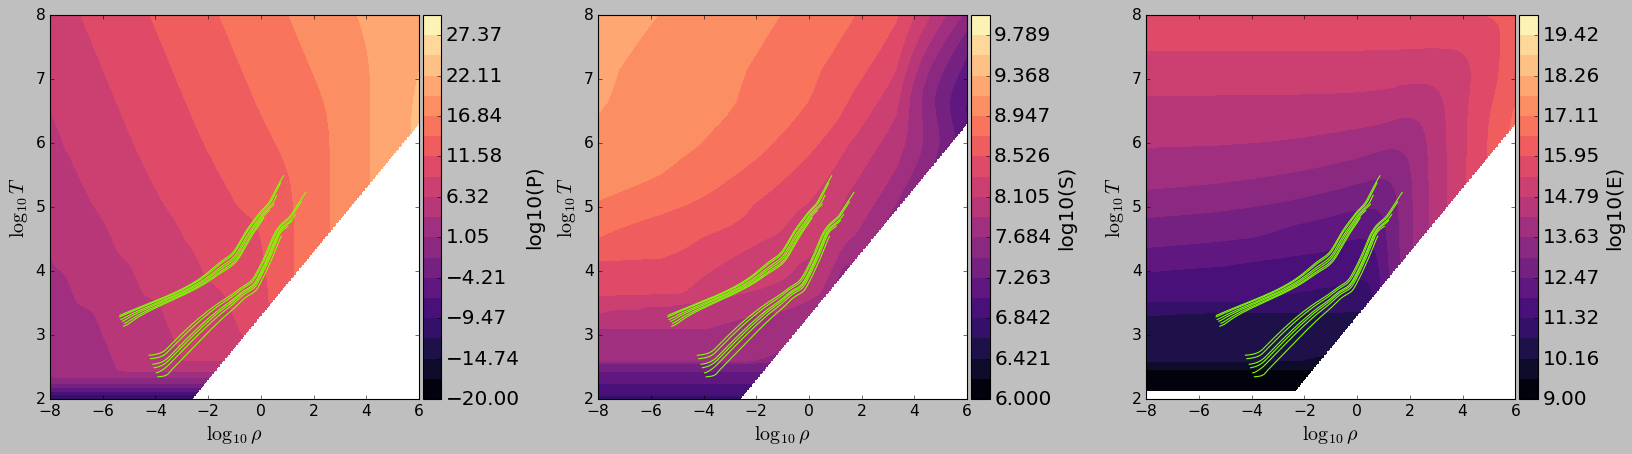

In [5]:
my_Z = meos.read_MESAtable("../meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend_100z00x.data")
my_Z_Trho = meos.reshapeQTgrid(my_Z,-8,6)[0]
print(type(my_Z_Trho))
print(np.shape(my_Z_Trho))

Z = meos.simple_table()
Z.X = 0.
Z.Y = 0.
Z.Z = 1.

Z.log10Tgrid = my_Z_Trho[:,:,0]
Z.log10rhogrid = my_Z_Trho[:,:,-1]

Z.log10Pgrid = my_Z_Trho[:,:,1]
Z.log10Sgrid = my_Z_Trho[:,:,3]
Z.log10Egrid = my_Z_Trho[:,:,2]

#Z.log10Pgrid = meos.fill_in_nans(Z.log10Pgrid,Z)
#Z.log10Sgrid = meos.fill_in_nans(Z.log10Sgrid,Z)
#Z.log10Egrid = meos.fill_in_nans(Z.log10Egrid,Z)

Z.compute_atomic_number()

meos.contourf_subplots_with_colorbars(nRow=1, nCol=3, 
                                xs=Z.log10rhogrid,
                                ys=Z.log10Tgrid,
                                zs=[Z.log10Pgrid,Z.log10Sgrid,Z.log10Egrid],
                                xlims=(-8,6),
                                ylims=(2,8),
                                zlims=[(-20,30),(6,10),(9,20)],
                                levels=20,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['log10(P)','log10(S)','log10(E)'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=[prof['logRho'] for prof in profiles], otherlines_y=[prof['logT'] for prof in profiles], 
                                species='Z', plot_interpolation_lines=False, savename=None)



/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1772: RuntimeWarning: invalid value encountered in log10
  zs=[np.log10(dP_drho),np.log10(-1*dS_drho),np.log10(np.abs(dE_drho)),np.log10(dP_dT),np.log10(dS_dT),np.log10(dE_dT)],
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1556: UserWarning: The following kwargs were not used by contour: 'shading'
  cs = axes[i,j].contourf(xs[i*nCol + j], ys[i*nCol + j], zs[i*nCol + j], shading='nearest', cmap=cmap[i*nCol + j], levels=levels[i*nCol+j])


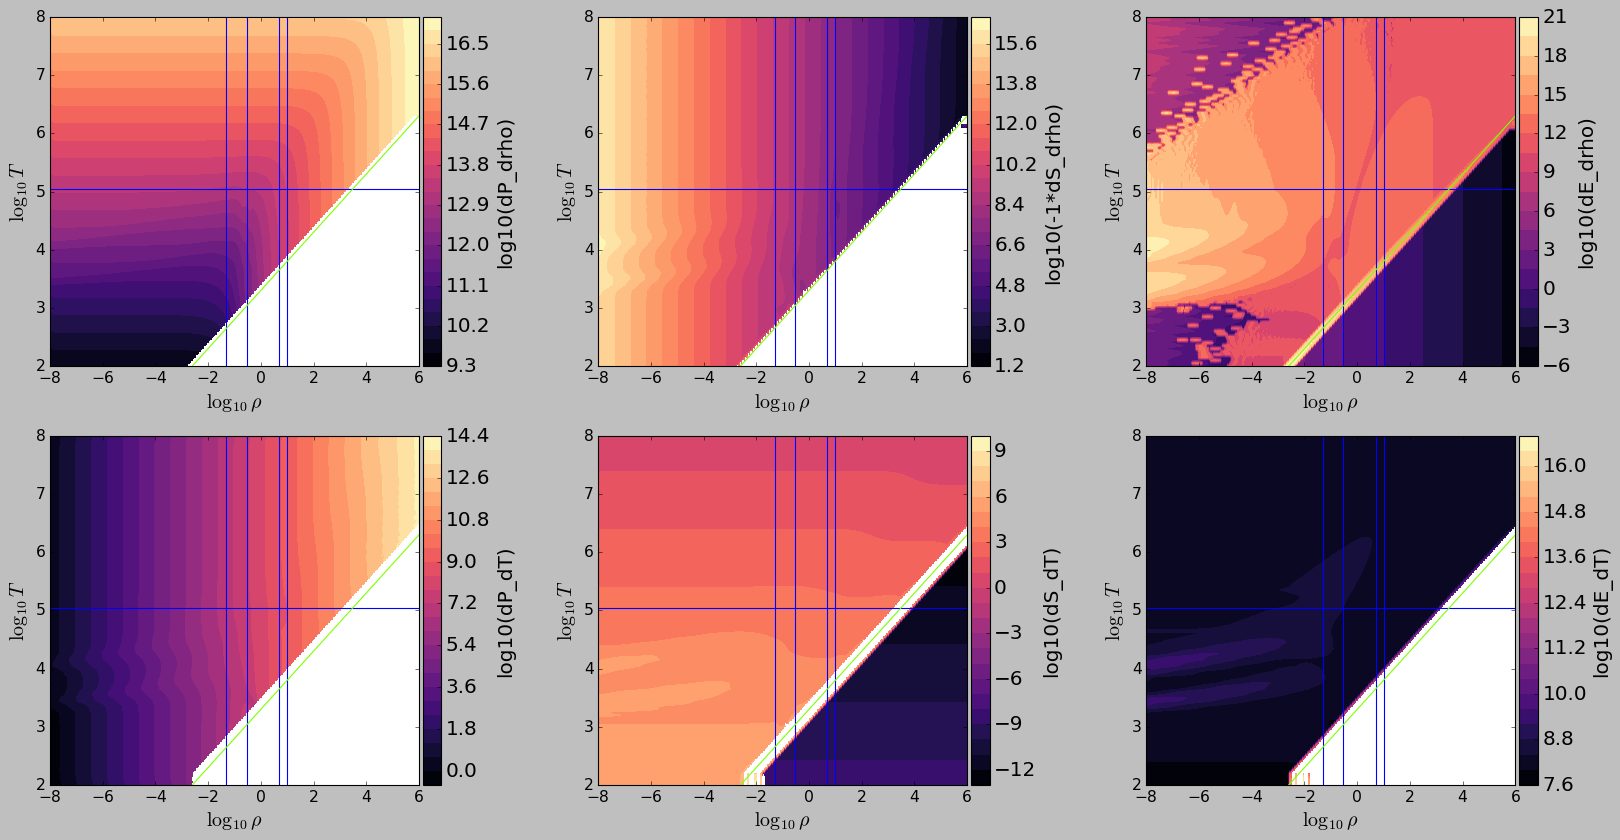

/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1772: RuntimeWarning: divide by zero encountered in log10
  zs=[np.log10(dP_drho),np.log10(-1*dS_drho),np.log10(np.abs(dE_drho)),np.log10(dP_dT),np.log10(dS_dT),np.log10(dE_dT)],


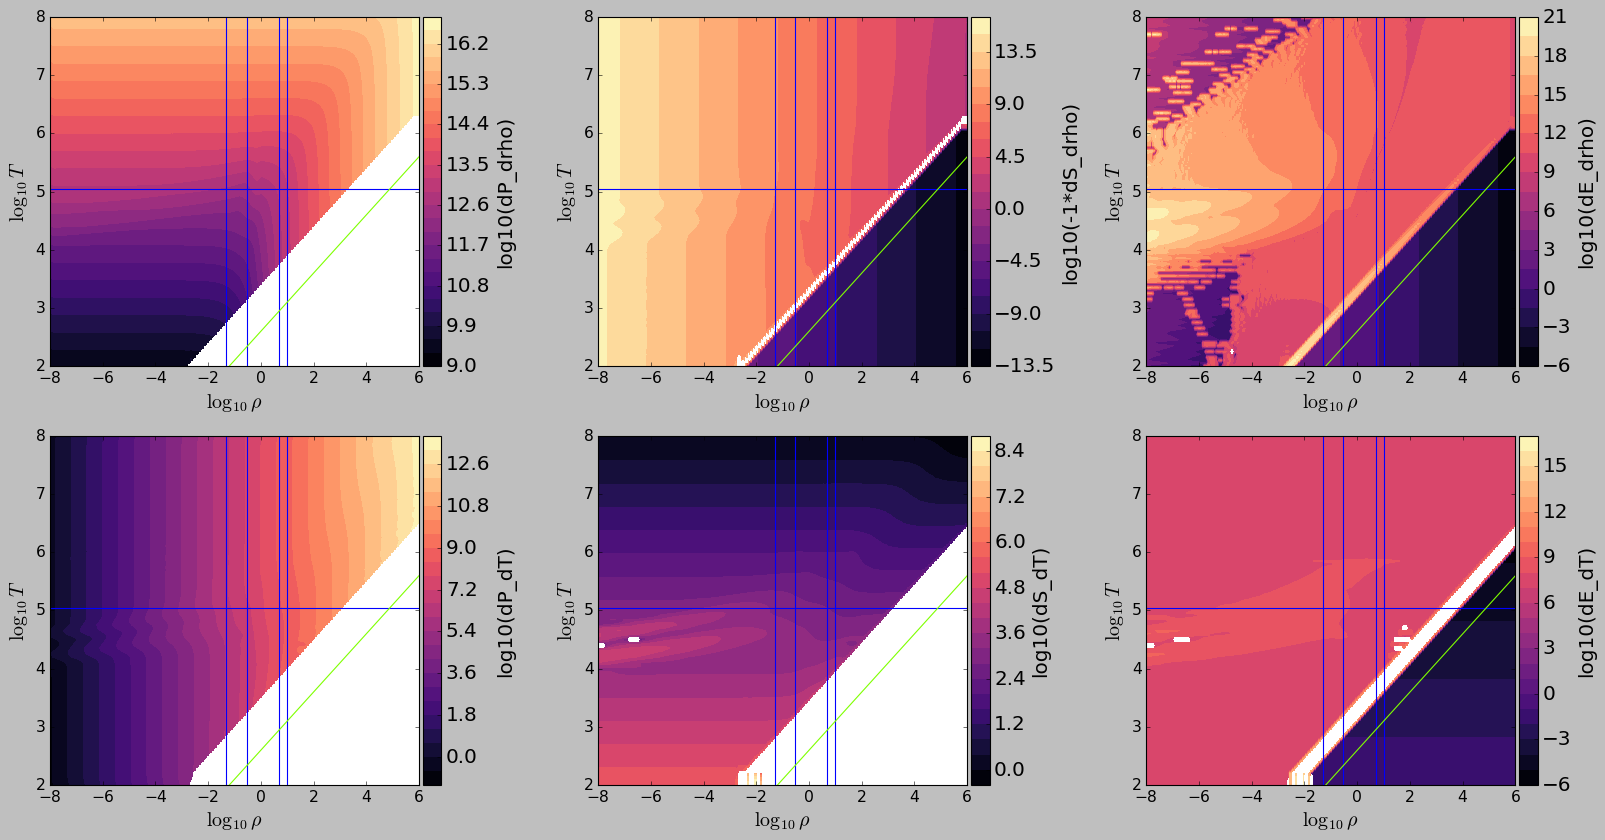

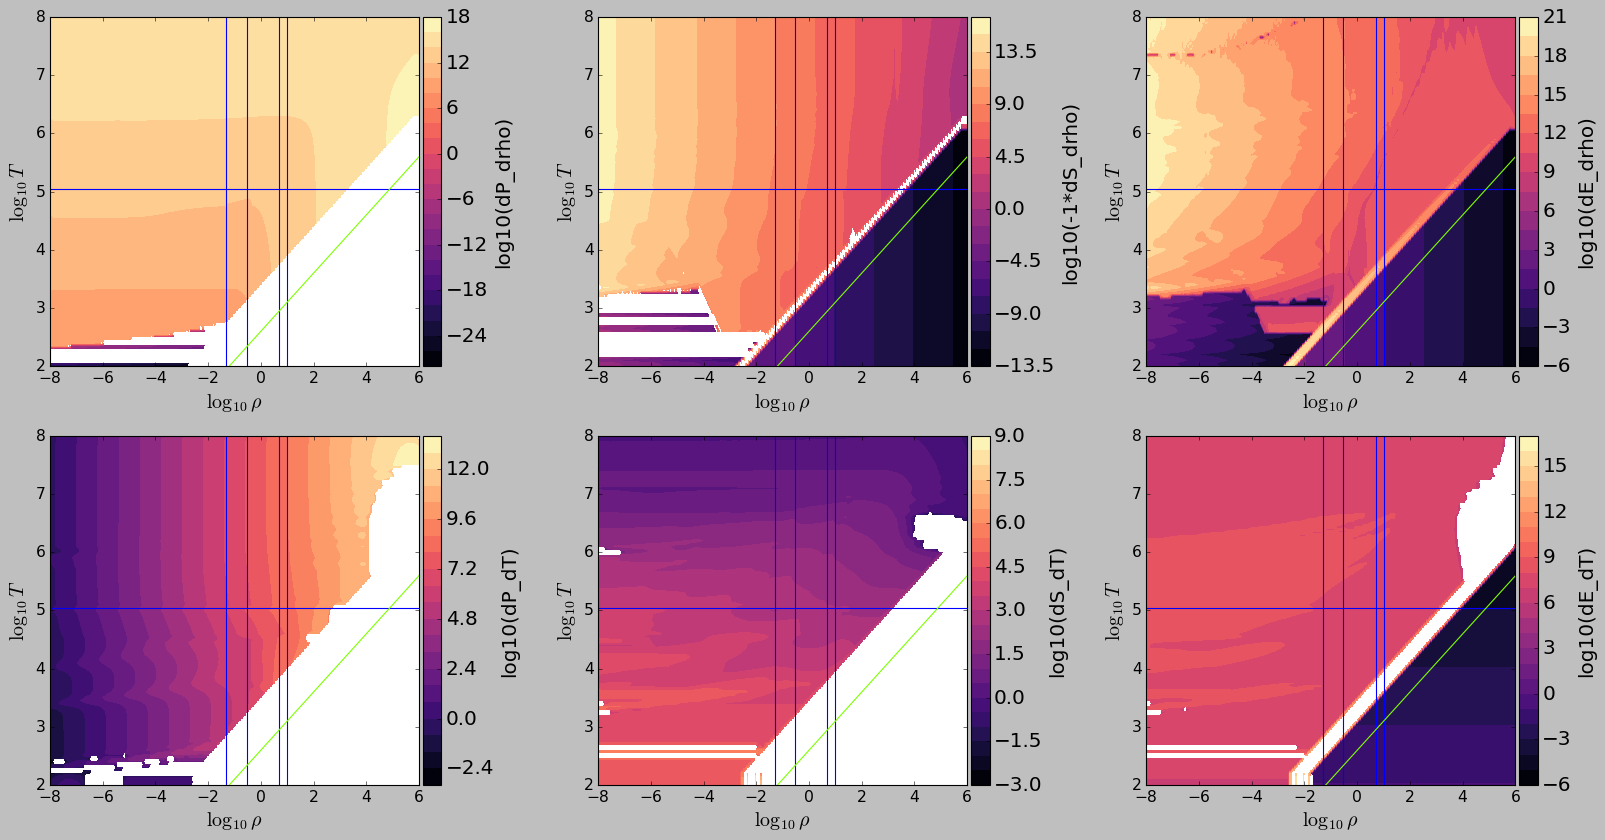

In [6]:
H_dP_drho_T, H_dS_drho_T, H_dE_drho_T, H_dP_dT_rho, H_dS_dT_rho, H_dE_dT_rho =  meos.finite_difference_PSE(cms19_H, 10**cms19_H.log10Pgrid,10**cms19_H.log10Sgrid,10**cms19_H.log10Egrid,
                                                                                                  species='H', maskUnphysicalRegion=False, plot=True, savename=None)

He_dP_drho_T, He_dS_drho_T, He_dE_drho_T, He_dP_dT_rho, He_dS_dT_rho, He_dE_dT_rho = meos.finite_difference_PSE(cms19_He, 10**cms19_He.log10Pgrid,10**cms19_He.log10Sgrid,10**cms19_He.log10Egrid,species='He', 
                                                                                                        maskUnphysicalRegion=False, plot=True, savename=None)

Z_dP_drho_T, Z_dS_drho_T, Z_dE_drho_T, Z_dP_dT_rho, Z_dS_dT_rho, Z_dE_dT_rho = meos.finite_difference_PSE(Z, 10**Z.log10Pgrid,10**Z.log10Sgrid,10**Z.log10Egrid,species='Z', 
                                                                                                        maskUnphysicalRegion=False, plot=True, savename=None)


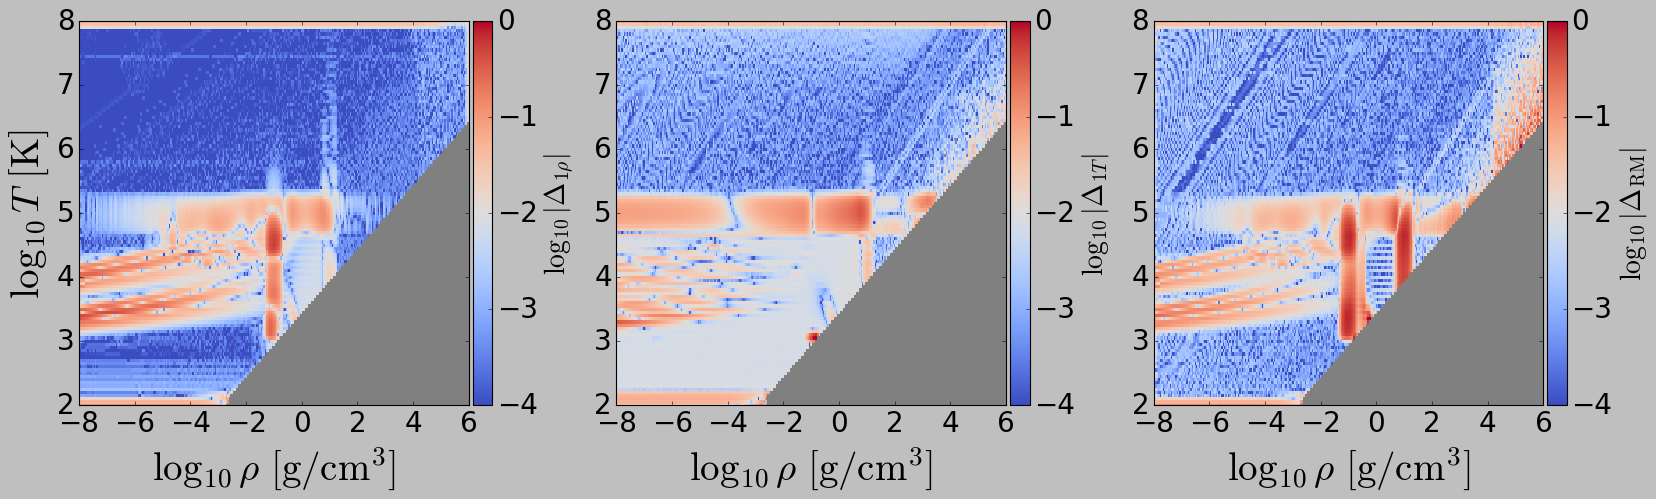

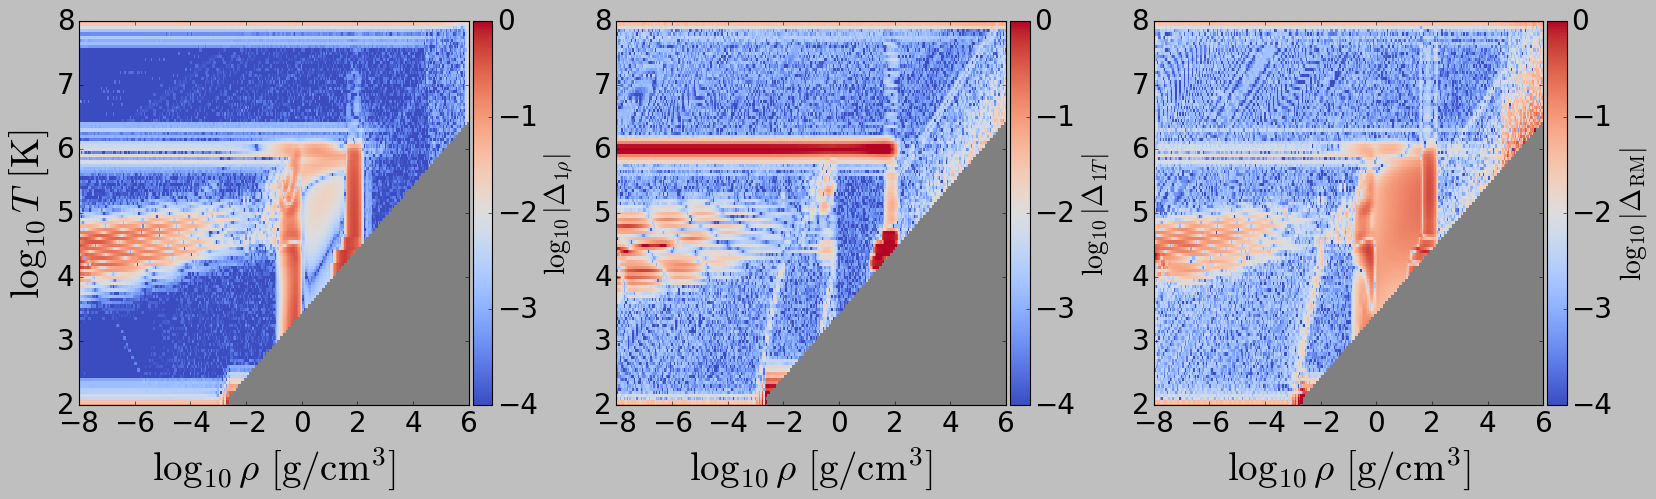

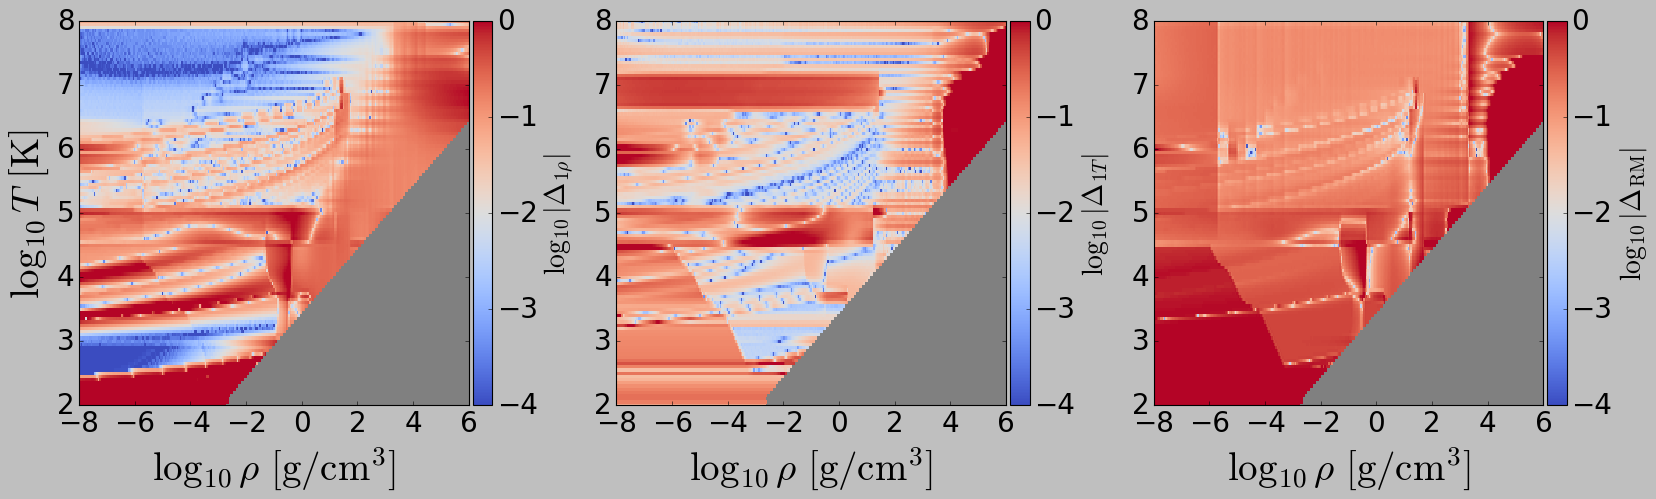

In [7]:
H_dpe, H_dse, H_dsp, H_a, H_b, H_c = meos.consistency_metrics(cms19_H, 10**cms19_H.log10Pgrid,10**cms19_H.log10Sgrid,10**cms19_H.log10Egrid,
                                                             order=6,species='H',maskUnphysicalRegion=True,plot=False,plot_tracks=False,paperplot=True, savename=None)

He_dpe, He_dse, He_dsp, He_a, He_b, He_c = meos.consistency_metrics(cms19_He, 10**cms19_He.log10Pgrid,10**cms19_He.log10Sgrid,10**cms19_He.log10Egrid,
                                                                    order=6,species='He',maskUnphysicalRegion=True,plot=False,plot_tracks=False,paperplot=True, savename=None)

Z_dpe, Z_dse, Z_dsp, Z_a, Z_b, Z_c = meos.consistency_metrics(Z, 10**Z.log10Pgrid,10**Z.log10Sgrid,10**Z.log10Egrid,
                                                              order=6,species='Z',maskUnphysicalRegion=True,plot=False,plot_tracks=False,paperplot=True, savename=None)
  

# numerical integration of system defined on lab notebook pages 156-157

In [8]:
def naive_grid_update(CMStable, P,S,E, order=6,gaussian_blur=None,species='H', ic='oom', plot=False, nUpdates=1, a=None, b=None, c=None):
    log10rho = CMStable.log10rhogrid
    log10T = CMStable.log10Tgrid
    
    rho = 10**CMStable.log10rhogrid
    T = 10**CMStable.log10Tgrid

    grid_rho = rho[:,0]
    grid_T = T[0]

    grid_log10rho = log10rho[:,0]
    grid_log10T = log10T[0]

    nrho = len(grid_rho)
    nT = len(grid_T)

    P_init = copy.deepcopy(P)
    S_init = copy.deepcopy(S)
    E_init = copy.deepcopy(E)

    if a is None and b is None and c is None:
        dP_drho_T, dS_drho_T, dE_drho_T, dP_dT_rho, dS_dT_rho, dE_dT_rho = meos.finite_difference_PSE(CMStable,P_init,S_init,E_init,species,maskUnphysicalRegion=False,plot=False,savename=None)
   
        dpe, dse, dsp, a, b, c = meos.consistency_metrics(CMStable,P_init,S_init,E_init,order=order,species='H',maskUnphysicalRegion=True,plot=False,plot_tracks=False,paperplot=False, savename=None)
    else:

        dP_drho_T, dS_drho_T, dE_drho_T, dP_dT_rho, dS_dT_rho, dE_dT_rho = meos.finite_difference_PSE(CMStable,P_init,S_init,E_init,species,maskUnphysicalRegion=False,plot=False,savename=None)
   
        dpe = (-1*a/P) + dP_drho_T - dP_drho_T
        dse = (-1*b/dE_dT_rho) + dP_drho_T - dP_drho_T
        dsp = (c*rho**2 / dP_dT_rho) + dP_drho_T - dP_drho_T
        
    if ic == 'random':
        np.random.seed(200)
        scale = 1.e2

        pi_mat_init = np.random.normal(loc=0.,scale=scale,size=(nrho,nT))
        sigma_mat_init = np.random.normal(loc=0.,scale=scale,size=(nrho,nT))
        epsilon_mat_init = np.random.normal(loc=0.,scale=scale,size=(nrho,nT))

        # make sure masked
        pi_mat_init = pi_mat_init + dpe - dpe
        sigma_mat_init = sigma_mat_init + dpe - dpe
        epsilon_mat_init = epsilon_mat_init + dpe - dpe

    elif ic == 'oom':
        epsilon_mat_init = a/rho

        sigma_mat_init = epsilon_mat_init/T + b
        
        pi_mat_init = (T*rho**2)*(c - (sigma_mat_init/rho))

        # scale
        epsilon_mat_init = epsilon_mat_init/np.max(epsilon_mat_init)
        sigma_mat_init = sigma_mat_init/np.max(sigma_mat_init)
        pi_mat_init = pi_mat_init/np.max(pi_mat_init)
        
    elif ic == 'ones':
        pi_mat_init = np.ones_like(rho)
        sigma_mat_init = np.ones_like(rho)
        epsilon_mat_init = np.ones_like(rho)
        
    del_logrho = 0.05
    del_logT = 0.05

    epsilon_mat = copy.deepcopy(epsilon_mat_init)
    sigma_mat = copy.deepcopy(sigma_mat_init)
    pi_mat = copy.deepcopy(pi_mat_init)

    log10rho_masked = np.round(log10rho + dpe - dpe, 2)
    log10T_masked = np.round(log10T + dpe - dpe, 2)

    grid_log10rho_masked = np.sort(np.unique(log10rho_masked.filled(fill_value=np.nan)))
    grid_log10T_masked = np.sort(np.unique(log10T_masked.filled(fill_value=np.nan)))
      
    grid_log10rho_masked = grid_log10rho_masked[~np.isnan(grid_log10rho_masked)]
    grid_log10T_masked = grid_log10T_masked[~np.isnan(grid_log10T_masked)]

    nrho_masked = len(grid_log10rho_masked)
    nT_masked = len(grid_log10T_masked)
    '''
    upper_i = np.arange(len(grid_log10rho))[grid_log10rho == grid_log10rho_masked[0]] + 10
    lower_i = np.arange(len(grid_log10rho))[grid_log10rho == grid_log10rho_masked[-1]] - 200
    left_j = np.arange(len(grid_log10T))[grid_log10T == grid_log10T_masked[0]] + 10
    right_j = np.arange(len(grid_log10T))[grid_log10T == grid_log10T_masked[-1]] - 10
    '''
    upper_i = 12
    lower_i = 80
    left_j = 6
    right_j = 114
    for k in range(nUpdates):
        small = 1.e-20
        if gaussian_blur is not None:
            sigma_mat = gaussian_filter(sigma_mat,gaussian_blur)
            epsilon_mat = gaussian_filter(epsilon_mat,gaussian_blur)
            pi_mat = gaussian_filter(pi_mat,gaussian_blur)
            
        # boundary conditions
        
        sigma_mat[upper_i, left_j] = small #sigma_mat_init[upper_i, left_j]
        sigma_mat[upper_i, right_j] = small #sigma_mat_init[upper_i, right_j]
        sigma_mat[lower_i, left_j] = small #sigma_mat_init[lower_i, left_j]
        sigma_mat[lower_i, right_j] = small #sigma_mat_init[lower_i, right_j]
        
        epsilon_mat[upper_i, left_j] = small #epsilon_mat_init[upper_i, left_j]
        epsilon_mat[upper_i, right_j] = small #epsilon_mat_init[upper_i, right_j]
        epsilon_mat[lower_i, left_j] = small #epsilon_mat_init[lower_i, left_j]
        epsilon_mat[lower_i, right_j] = small #epsilon_mat_init[lower_i, right_j]
        
        pi_mat[upper_i, left_j] = small #pi_mat_init[upper_i, left_j]
        pi_mat[upper_i, right_j] = small #pi_mat_init[upper_i, right_j]
        pi_mat[lower_i, left_j] = small #pi_mat_init[lower_i, left_j]
        pi_mat[lower_i, right_j] = small #pi_mat_init[lower_i, right_j]
        
        '''
        sigma_mat[upper_i, left_j] = sigma_mat_init[upper_i, left_j]
        sigma_mat[upper_i, right_j] = sigma_mat_init[upper_i, right_j]
        sigma_mat[lower_i, left_j] = sigma_mat_init[lower_i, left_j]
        sigma_mat[lower_i, right_j] = sigma_mat_init[lower_i, right_j]
        
        epsilon_mat[upper_i, left_j] = epsilon_mat_init[upper_i, left_j]
        epsilon_mat[upper_i, right_j] = epsilon_mat_init[upper_i, right_j]
        epsilon_mat[lower_i, left_j] = epsilon_mat_init[lower_i, left_j]
        epsilon_mat[lower_i, right_j] = epsilon_mat_init[lower_i, right_j]
        
        pi_mat[upper_i, left_j] = pi_mat_init[upper_i, left_j]
        pi_mat[upper_i, right_j] = pi_mat_init[upper_i, right_j]
        pi_mat[lower_i, left_j] = pi_mat_init[lower_i, left_j]
        pi_mat[lower_i, right_j] = pi_mat_init[lower_i, right_j]
        '''

        edge=5
        
        for i in range(edge,nrho-edge):
            min_j = np.argmin(log10T_masked[i])
            for j in range(min_j+edge,nT-edge):
                # using a forward diff rather than a central diff here to get a cancellation
                #del_T = T[i,j] * (10**del_logT - 1)
                #del_rho = rho[i,j] * (10**del_logrho - 1)
                # better results
                #pi_mat[i,j] = (del_T/(del_T + T[i,j])) * ( (T[i,j]/del_T) * pi_mat[i,j+1]  - a[i,j] + (rho[i,j]**2 /del_rho)*(epsilon_mat[i+1,j]-epsilon_mat[i,j]) )
                # worse results
                #pi_mat[i,j+1] = ((del_T + T[i,j])/T[i,j]) * pi_mat[i,j]  + (del_T/T[i,j])* a[i,j] - (rho[i,j]**2 /del_rho)*(del_T/T[i,j])*(epsilon_mat[i+1,j]-epsilon_mat[i,j])

                # central diff
                two_del_T = T[i,j] * (10**del_logT - 10**(-1*del_logT))
                two_del_rho = rho[i,j] * (10**del_logrho - 10**(-1*del_logrho))
                del_T = T[i,j] * (10**(0.5*del_logT) - 10**(-0.5*del_logT))
                del_rho = rho[i,j] * (10**(0.5*del_logrho) - 10**(-0.5*del_logrho))

                # option 1
                
                # numerically unstable
                #pi_mat[i,j] = (T[i,j]/two_del_T) * (pi_mat[i, j+1] - pi_mat[i, j-1]) - a[i,j] + (rho[i,j]**2/two_del_rho) * (epsilon_mat[i+1,j] - epsilon_mat[i-1,j])
                # numerically stable
                pi_mat[i, j+1] = (two_del_T/T[i,j])*pi_mat[i,j] + pi_mat[i,j-1] + (two_del_T/T[i,j])*( a[i,j] - (rho[i,j]**2/two_del_rho)*(epsilon_mat[i+1,j] - epsilon_mat[i-1,j]) )

                # option 2
                #dsq_epsilon_mat = (1/(two_del_T * two_del_rho)) * (epsilon_mat[i+1,j+1] + epsilon_mat[i-1,j+1] + epsilon_mat[i+1,j-1] + epsilon_mat[i-1,j-1] + 4*epsilon_mat[i,j] - 2*(epsilon_mat[i+1,j] + epsilon_mat[i-1,j] + epsilon_mat[i,j+1] + epsilon_mat[i,j-1]))
                # tends to run away to high pi values, but good dpe/dse/dsp results
                #pi_mat[i,j] = 0.5*(pi_mat[i,j+1] + pi_mat[i,j-1] - (del_T**2 * rho[i,j]**2 * ( dc_dT[i,j] - (1/T[i,j]) * (dsq_epsilon_mat + db_drho[i,j])  ) ) ) 
                # numerically worse
                #pi_mat[i,j+1] = 2*pi_mat[i,j] - pi_mat[i,j-1] + (del_T**2 * rho[i,j]**2 * ( dc_dT[i,j] - (1/T[i,j]) * (dsq_epsilon_mat + db_drho[i,j])  ) ) 

                # option 3
                #dsq_sigma_mat = (1/(two_del_T * two_del_rho)) * (sigma_mat[i+1,j+1] + sigma_mat[i-1,j+1] + sigma_mat[i+1,j-1] + sigma_mat[i-1,j-1] + 4*sigma_mat[i,j] - 2*(sigma_mat[i+1,j] + sigma_mat[i-1,j] + sigma_mat[i,j+1] + sigma_mat[i,j-1]))
                # also tends to run away to high pi values, but good dpe/dse/dsp results.
                #pi_mat[i,j] = 0.5* (pi_mat[i,j+1] + pi_mat[i,j-1] - del_T**2 * ((1/T[i,j]) * da_dT[i,j] - rho[i,j]**2 * dsq_sigma_mat + (rho[i,j]**2/T[i,j])*db_drho[i,j] ) ) 

        
        for j in range(edge,nT-edge):
            max_i = np.argmax(log10rho_masked[:,j]) 
            for i in range(edge,max_i-edge):
                # forward diff
                #del_T = T[i,j] * (10**del_logT - 1)
                #del_rho = rho[i,j] * (10**del_logrho - 1)
                #sigma_mat[i+1,j] = sigma_mat[i,j] + del_rho*( c[i,j] - (1/(rho[i,j]**2 * del_T))*(pi_mat[i,j+1] - pi_mat[i,j]) )

                # central diff
                two_del_T = T[i,j] * (10**del_logT - 10**(-1*del_logT))
                two_del_rho = rho[i,j] * (10**del_logrho - 10**(-1*del_logrho))
                sigma_mat[i+1,j] = sigma_mat[i-1,j] + two_del_rho*( c[i,j] - (1/(rho[i,j]**2 * two_del_T))*(pi_mat[i,j+1] - pi_mat[i,j-1]) )

        
        for i in range(edge,nrho-edge):
            min_j = np.argmin(log10T_masked[i])
            for j in range(min_j+edge,nT-edge):
                # forward diff
                #del_T = T[i,j] * (10**del_logT - 1)
                #del_rho = rho[i,j] * (10**del_logrho - 1)
                #epsilon_mat[i,j+1] = epsilon_mat[i,j] + T[i,j]*(sigma_mat[i,j+1] - sigma_mat[i,j]) - del_T*b[i,j]

                # central diff
                two_del_T = T[i,j] * (10**del_logT - 10**(-1*del_logT))
                two_del_rho = rho[i,j] * (10**del_logrho - 10**(-1*del_logrho))
                epsilon_mat[i,j+1] = epsilon_mat[i,j-1] + T[i,j]*(sigma_mat[i,j+1] - sigma_mat[i,j-1]) - two_del_T*b[i,j]

        
    if plot is True:
        plot_line_x = np.linspace(-8,8,100)
        try:
            plot_line_y = 3.3 + (1./2.)*plot_line_x + np.log10(CMStable.atomic_number) - (5./3)*np.log10(CMStable.mass_number)
        except TypeError:
            plot_line_y = -2*np.ones_like(plot_line_x)
        meos.contourf_subplots_with_colorbars(nRow=3, nCol=3, 
                                xs=log10rho,
                                ys=log10T,
                                #zs=[pi_mat_init/P, sigma_mat_init/S, epsilon_mat_init/E,
                                #    pi_mat/P, sigma_mat/S, epsilon_mat/E],
                                zs=[np.log10(np.abs(pi_mat_init/P_init)), np.log10(np.abs(sigma_mat_init/S_init)), np.log10(np.abs(epsilon_mat_init/E_init)),
                                    np.log10(pi_mat/P_init), np.log10(sigma_mat/S_init), np.log10(epsilon_mat/E_init),
                                   np.log10(-pi_mat/P_init), np.log10(-sigma_mat/S_init), np.log10(-epsilon_mat/E_init)],
                                xlims=(-8,6),
                                ylims=(2,8),
                                #zlims=[(-25,-15),(-20,-8),(-22,-12),(-10,10),(-10,10),(-10,10),(-10,10),(-10,10),(-10,10)], 
                                zlims=None,
                                levels=25,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['pi_init','sigma_init','epsilon_init','pi, {0} updates'.format(nUpdates),'sigma, {0} updates'.format(nUpdates),'epsilon, {0} updates'.format(nUpdates),'-pi, {0} updates'.format(nUpdates),'-sigma, {0} updates'.format(nUpdates),'-epsilon, {0} updates'.format(nUpdates)],
                                cmap='magma',
                                vlines=[log10rho[upper_i,0],log10rho[lower_i,0]],#,-3.45,-0.85,0.45], 
                                hlines=[log10T[0,left_j],log10T[0,right_j]], 
                                otherlines_x=[plot_line_x], otherlines_y=[plot_line_y], 
                                species=species, plot_interpolation_lines=True, savename=None)

    return pi_mat, sigma_mat, epsilon_mat

/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1814: RuntimeWarning: invalid value encountered in divide
  dse = (T * (dS_dT/dE_dT)) - 1.0
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_52181/155179258.py:211: RuntimeWarning: invalid value encountered in log10
  np.log10(pi_mat/P_init), np.log10(sigma_mat/S_init), np.log10(epsilon_mat/E_init),
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_52181/155179258.py:212: RuntimeWarning: invalid value encountered in log10
  np.log10(-pi_mat/P_init), np.log10(-sigma_mat/S_init), np.log10(-epsilon_mat/E_init)],


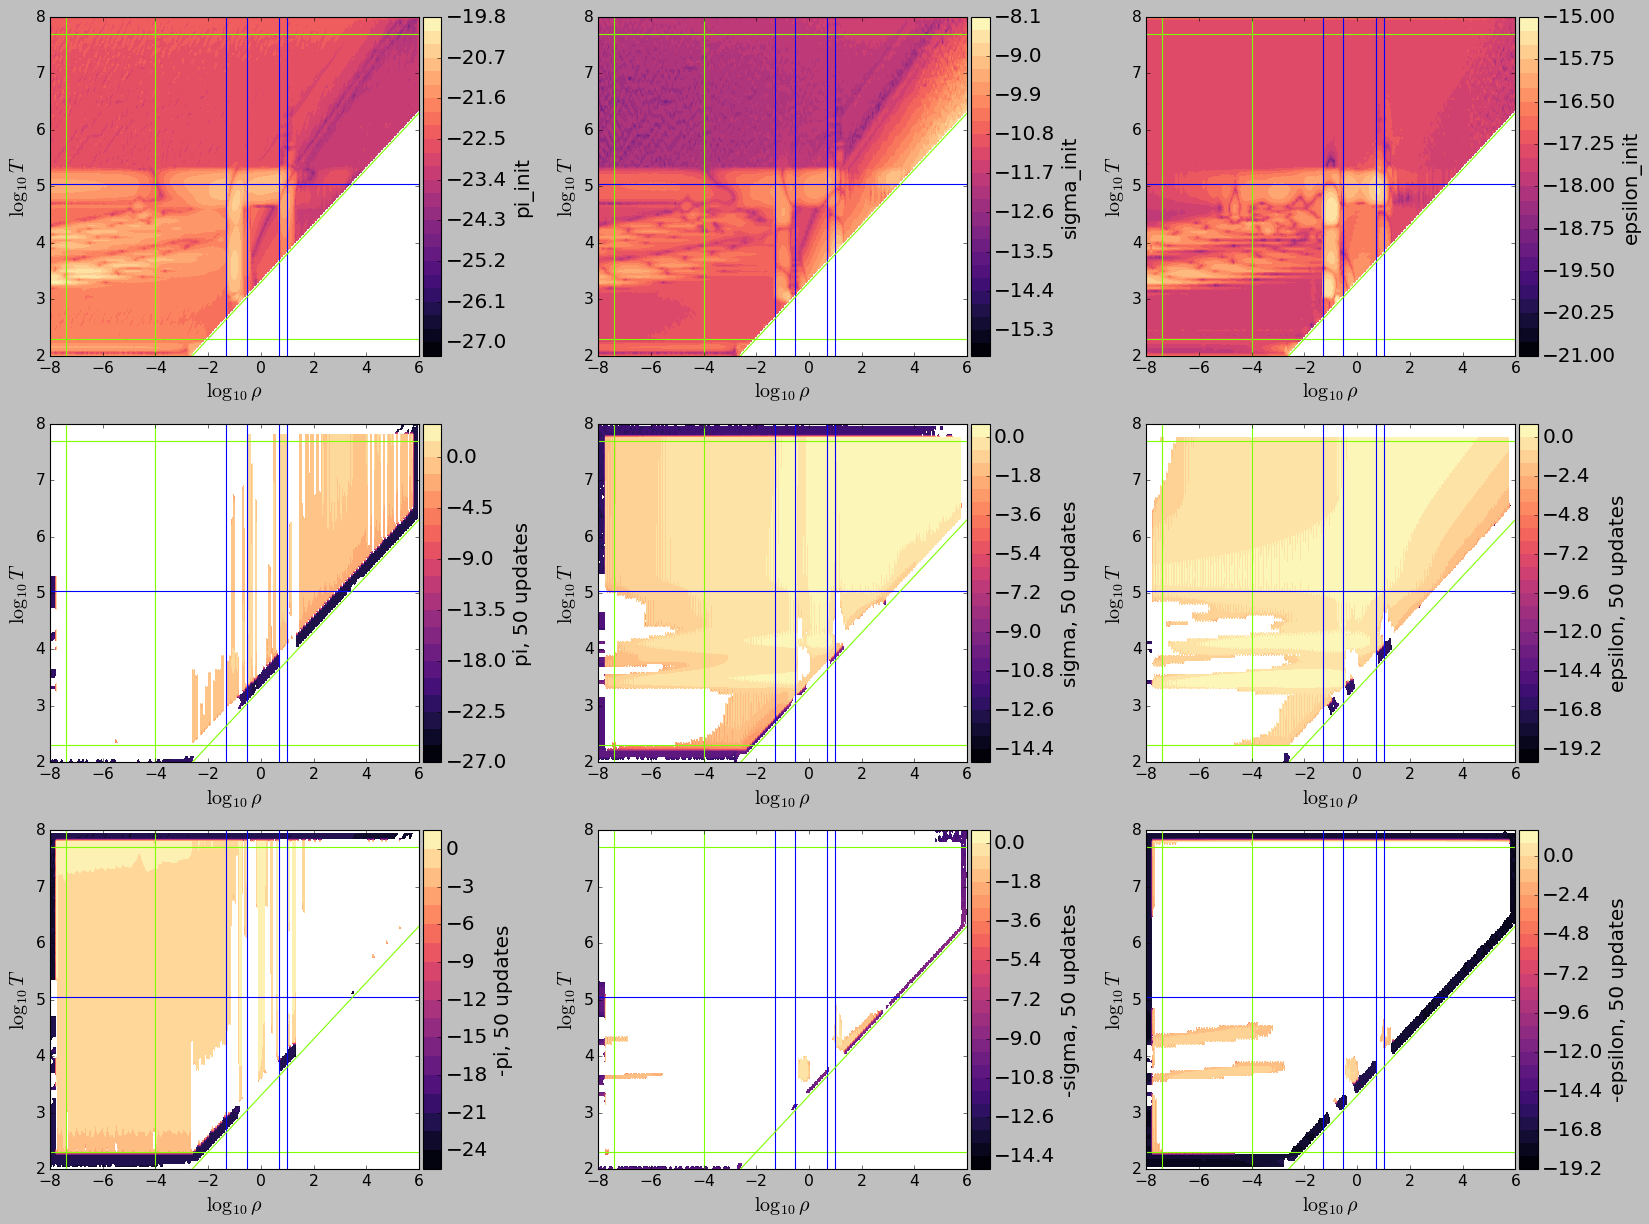

"\nHe_pi_, He_sigma_, He_epsilon_ = naive_grid_update(cms19_He, 10**cms19_He.log10Pgrid,10**cms19_He.log10Sgrid,10**cms19_He.log10Egrid, order=2, gaussian_blur=None, \n                                          species='He', ic='oom',nUpdates=10, plot=True)\n\nZ_pi_, Z_sigma_, Z_epsilon_ = naive_grid_update(Z, 10**Z.log10Pgrid,10**Z.log10Sgrid,10**Z.log10Egrid, order=2, gaussian_blur=None,\n                                          species='Z', ic='oom',nUpdates=10, plot=True)\n"

In [9]:
H_pi_, H_sigma_, H_epsilon_ = naive_grid_update(cms19_H, 10**cms19_H.log10Pgrid,10**cms19_H.log10Sgrid,10**cms19_H.log10Egrid, order=2,gaussian_blur=None,
                                          species='H', ic='oom',nUpdates=50, plot=True)
'''
He_pi_, He_sigma_, He_epsilon_ = naive_grid_update(cms19_He, 10**cms19_He.log10Pgrid,10**cms19_He.log10Sgrid,10**cms19_He.log10Egrid, order=2, gaussian_blur=None, 
                                          species='He', ic='oom',nUpdates=10, plot=True)

Z_pi_, Z_sigma_, Z_epsilon_ = naive_grid_update(Z, 10**Z.log10Pgrid,10**Z.log10Sgrid,10**Z.log10Egrid, order=2, gaussian_blur=None,
                                          species='Z', ic='oom',nUpdates=10, plot=True)
'''

In [10]:
print(H_pi_)

[[1.553410909139299e-20 -3.3842076721309964e-21 -1.3557931480622703e-20
  ... -8.96785898239776e-15 -5.424390285988738e-15 1.1881379522931472e-14]
 [1.9109621003934455e-20 -1.7359189889491412e-21 -1.6674623387075987e-20
  ... -8.46610616240914e-15 -7.170972113367273e-15 1.2184216684945031e-14]
 [2.0918355149382073e-20 3.196119634971388e-22 -1.7412680296299792e-20
  ... -4.858217851039263e-15 -9.302180056329736e-15 8.659375698927867e-15]
 ...
 [-- -- -- ... 0.045108417588944065 0.03805692954557525
  0.7435287929197215]
 [-- -- -- ... 0.22338867622392986 0.05038649072138669 1.0]
 [-- -- -- ... -0.6977900739645209 -1.1400314900393602
  -0.19756914697288075]]


In [11]:
H_P_adj = 10**cms19_H.log10Pgrid + H_pi_
H_S_adj = 10**cms19_H.log10Sgrid + H_sigma_
H_E_adj = 10**cms19_H.log10Egrid + H_epsilon_
'''
He_P_adj = 10**cms19_He.log10Pgrid + He_pi_
He_S_adj = 10**cms19_He.log10Sgrid + He_sigma_
He_E_adj = 10**cms19_He.log10Egrid + He_epsilon_

Z_P_adj = 10**Z.log10Pgrid + Z_pi_
Z_S_adj = 10**Z.log10Sgrid + Z_sigma_
Z_E_adj = 10**Z.log10Egrid + Z_epsilon_
'''

'\nHe_P_adj = 10**cms19_He.log10Pgrid + He_pi_\nHe_S_adj = 10**cms19_He.log10Sgrid + He_sigma_\nHe_E_adj = 10**cms19_He.log10Egrid + He_epsilon_\n\nZ_P_adj = 10**Z.log10Pgrid + Z_pi_\nZ_S_adj = 10**Z.log10Sgrid + Z_sigma_\nZ_E_adj = 10**Z.log10Egrid + Z_epsilon_\n'

In [12]:
meos.contourf_subplots_with_colorbars(nRow=1, nCol=3, 
                                xs=cms19_H.log10rhogrid,
                                ys=cms19_H.log10Tgrid,
                                zs=[np.log10(H_P_adj),np.log10(H_S_adj),np.log10(H_E_adj)],
                                xlims=(-8,6),
                                ylims=(2,8),
                                zlims=None,
                                levels=25,
                                xlabels=r'$\log_{10}\rho\ [\mathrm{g/cm}^3]$',
                                ylabels=r'$\log_{10}T\ [\mathrm{K}]$',
                                #zlabels=[r'$\log_{10}(P_{\mathrm{{orig}}}+\varpi)$',r'$\log_{10}(S_{\mathrm{{orig}}}+\sigma)$',r'$\log_{10}(E_{\mathrm{{orig}}}+\epsilon)$'],
                                zlabels=[r'$\log_{10}\bar{P}$',r'$\log_{10}\bar{S}$',r'$\log_{10}\bar{E}$'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename="./paper_figures/H_PSE_after_numerical_integration.pdf",paperplot=True)


meos.contourf_subplots_with_colorbars(nRow=1, nCol=3, 
                                xs=cms19_H.log10rhogrid,
                                ys=cms19_H.log10Tgrid,
                                zs=[H_P_adj/10**cms19_H.log10Pgrid,H_S_adj/10**cms19_H.log10Sgrid,H_E_adj/10**cms19_H.log10Egrid],
                                xlims=(-8,6),
                                ylims=(2,8),
                                zlims=(0.5,1.5),
                                levels=25,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['H_P_adj/H_P_orig','H_S_adj/H_S_orig','H_E_adj/H_E_orig'],
                                cmap='coolwarm', vlines=None, hlines=None, otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename="./paper_figures/H_PSE_ratio_to_original_after_numerical_integration.pdf")

'''
meos.contourf_subplots_with_colorbars(nRow=1, nCol=3, 
                                xs=cms19_He.log10rhogrid,
                                ys=cms19_He.log10Tgrid,
                                zs=[np.log10(He_P_adj),np.log10(He_S_adj),np.log10(He_E_adj)],
                                xlims=(-8,6),
                                ylims=(2,8),
                                zlims=None,
                                levels=25,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['log10(He_P_adj)','log10(He_S_adj)','log10(He_E_adj)'],
                                cmap='magma', vlines=[-3.45,-0.85,0.45], hlines=None, otherlines_x=[prof['logRho'] for prof in profiles], otherlines_y=[prof['logT'] for prof in profiles], 
                                species='He', plot_interpolation_lines=True, savename=None)

meos.contourf_subplots_with_colorbars(nRow=1, nCol=3, 
                                xs=Z.log10rhogrid,
                                ys=Z.log10Tgrid,
                                zs=[np.log10(Z_P_adj),np.log10(Z_S_adj),np.log10(Z_E_adj)],
                                xlims=(-8,6),
                                ylims=(2,8),
                                zlims=None,
                                levels=25,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['log10(Z_P_adj)','log10(Z_S_adj)','log10(Z_E_adj)'],
                                cmap='magma', vlines=[-3.45,-0.85,0.45], hlines=None, otherlines_x=[prof['logRho'] for prof in profiles], otherlines_y=[prof['logT'] for prof in profiles], 
                                species='Z', plot_interpolation_lines=True, savename=None)

'''


<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_52181/1303243238.py:31: SyntaxWarning: invalid escape sequence '\l'
  '''
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_52181/1303243238.py:4: RuntimeWarning: invalid value encountered in log10
  zs=[np.log10(H_P_adj),np.log10(H_S_adj),np.log10(H_E_adj)],
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1559: UserWarning: The following kwargs were not used by contour: 'shading'
  cs = axes[i,j].contourf(xs[i*nCol + j], ys[i*nCol + j], zs[i*nCol + j], shading='nearest', cmap=cmap[i*nCol + j], levels=np.linspace(zlims[i*nCol+j][0],zlims[i*nCol+j][1],levels[i*nCol+j]))


"\nmeos.contourf_subplots_with_colorbars(nRow=1, nCol=3, \n                                xs=cms19_He.log10rhogrid,\n                                ys=cms19_He.log10Tgrid,\n                                zs=[np.log10(He_P_adj),np.log10(He_S_adj),np.log10(He_E_adj)],\n                                xlims=(-8,6),\n                                ylims=(2,8),\n                                zlims=None,\n                                levels=25,\n                                xlabels=r'$\\log_{10}\rho$',\n                                ylabels=r'$\\log_{10}T$',\n                                zlabels=['log10(He_P_adj)','log10(He_S_adj)','log10(He_E_adj)'],\n                                cmap='magma', vlines=[-3.45,-0.85,0.45], hlines=None, otherlines_x=[prof['logRho'] for prof in profiles], otherlines_y=[prof['logT'] for prof in profiles], \n                                species='He', plot_interpolation_lines=True, savename=None)\n\nmeos.contourf_subplots_with_colorbars(nRow=

/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1772: RuntimeWarning: invalid value encountered in log10
  zs=[np.log10(dP_drho),np.log10(-1*dS_drho),np.log10(np.abs(dE_drho)),np.log10(dP_dT),np.log10(dS_dT),np.log10(dE_dT)],
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1556: UserWarning: The following kwargs were not used by contour: 'shading'
  cs = axes[i,j].contourf(xs[i*nCol + j], ys[i*nCol + j], zs[i*nCol + j], shading='nearest', cmap=cmap[i*nCol + j], levels=levels[i*nCol+j])


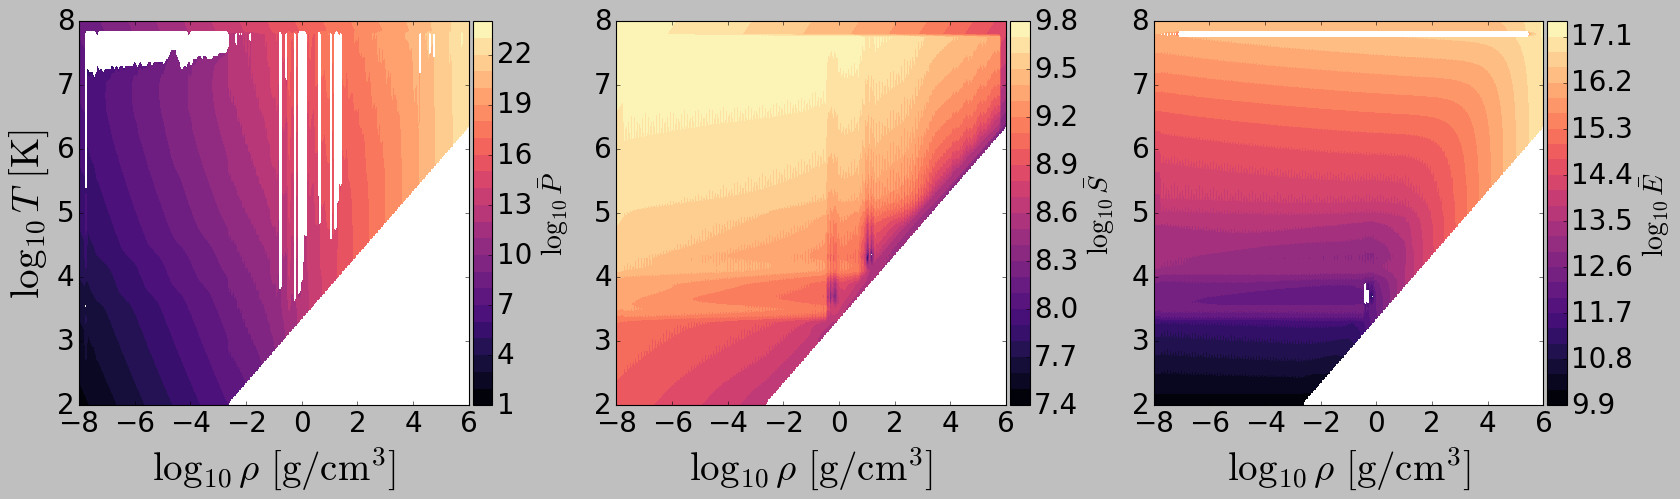

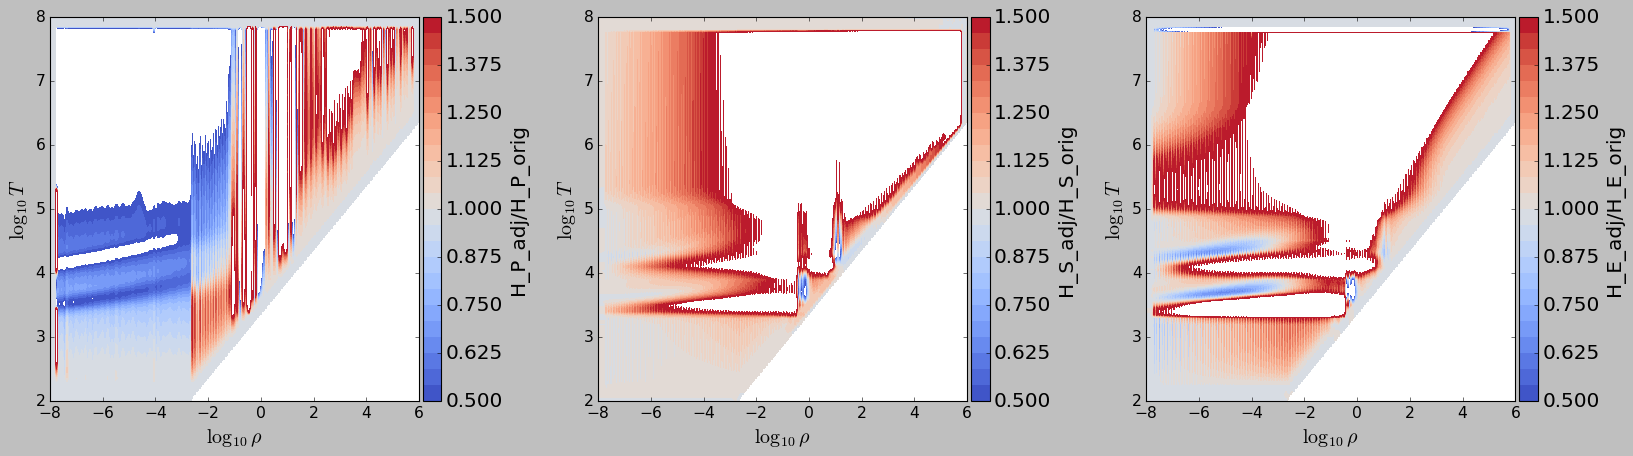

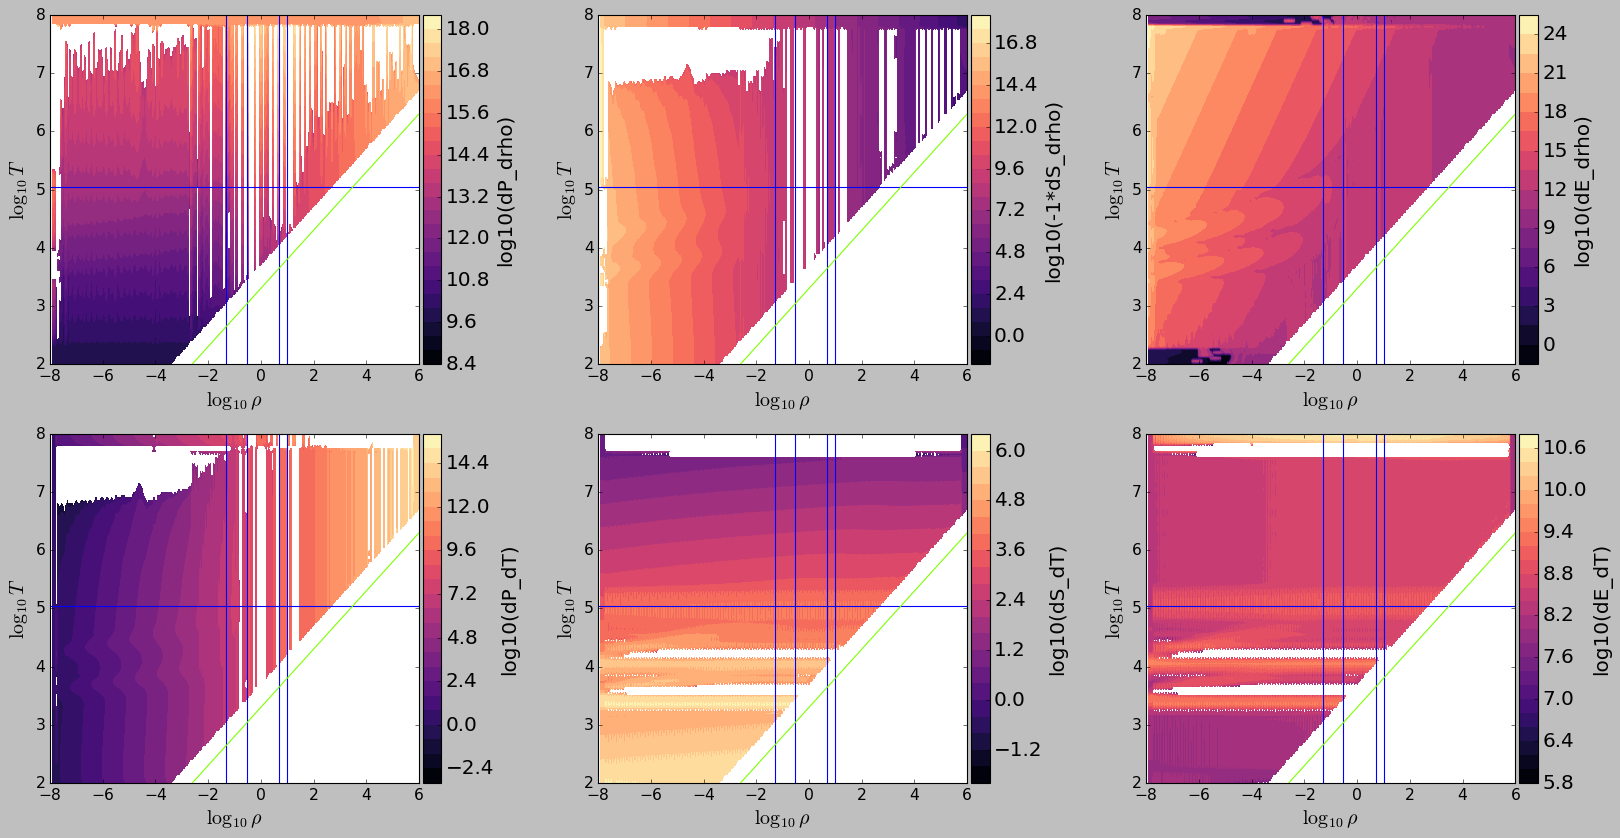

In [13]:
H_dP_drho_T_1, H_dS_drho_T_1, H_dE_drho_T_1, H_dP_dT_rho_1, H_dS_dT_rho_1, H_dE_dT_rho_1 =  meos.finite_difference_PSE(cms19_H, H_P_adj, H_S_adj, H_E_adj,
                                                                                                  species='H', maskUnphysicalRegion=True, plot=True, savename=None)


H_dpe_1, H_dse_1, H_dsp_1, H_a_1, H_b_1, H_c_1 = meos.consistency_metrics(cms19_H, H_P_adj, H_S_adj, H_E_adj,order=2,species='H',maskUnphysicalRegion=True,plot=False,plot_tracks=True,profiles=profiles,paperplot=True, savename="./paper_figures/H_consistency_after_numerical_integration.pdf")


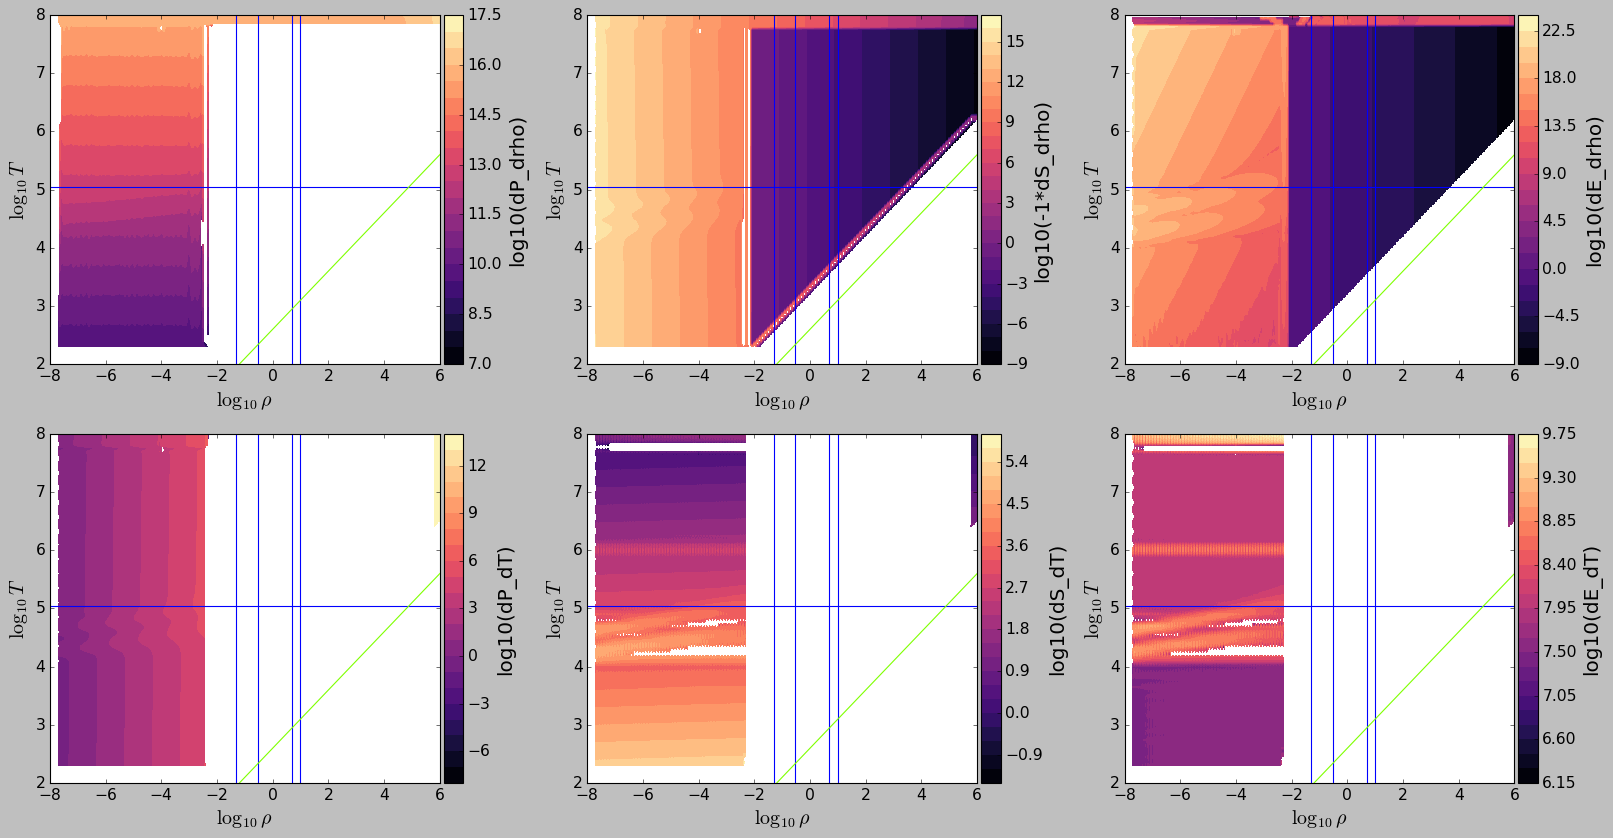

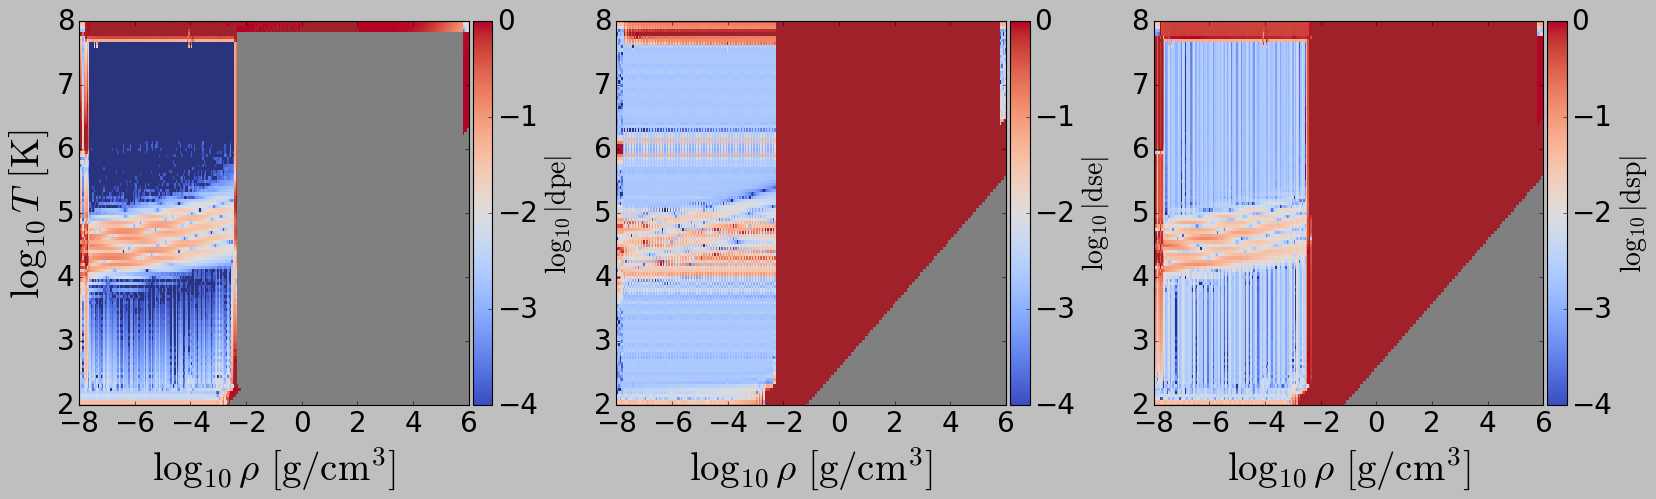

In [107]:
He_dP_drho_T_1, He_dS_drho_T_1, He_dE_drho_T_1, He_dP_dT_rho_1, He_dS_dT_rho_1, He_dE_dT_rho_1 =  meos.finite_difference_PSE(cms19_He, He_P_adj, He_S_adj, He_E_adj,
                                                                                                  species='He', maskUnphysicalRegion=True, plot=True, savename=None)


He_dpe_1, He_dse_1, He_dsp_1, He_a_1, He_b_1, He_c_1 = meos.consistency_metrics(cms19_He, He_P_adj, He_S_adj, He_E_adj,order=6,species='He',maskUnphysicalRegion=True,plot=False,plot_tracks=False,paperplot=True, savename=None)


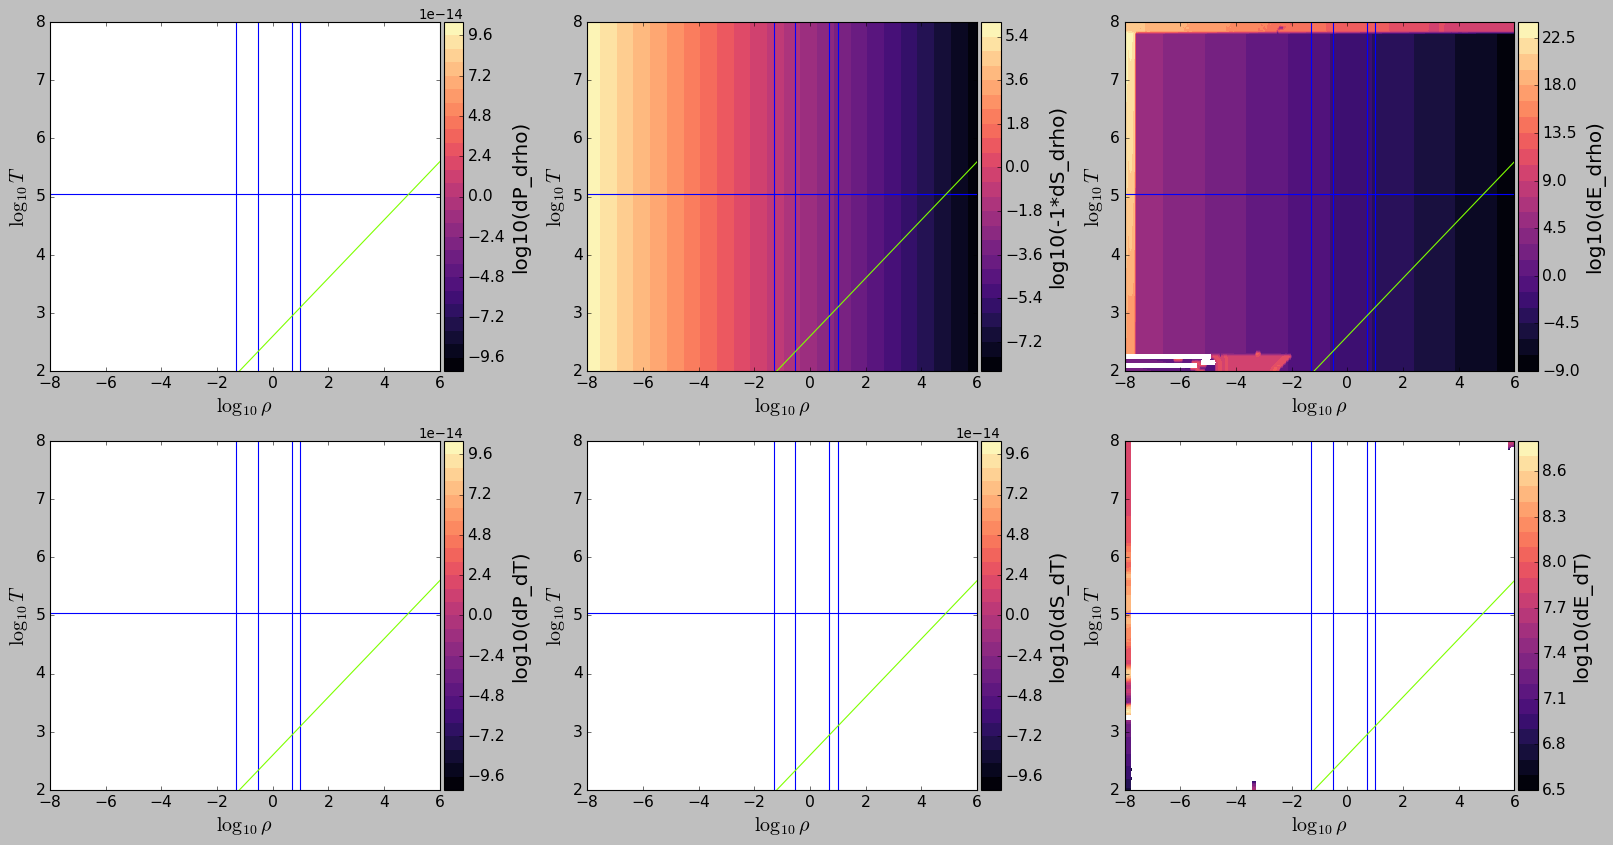

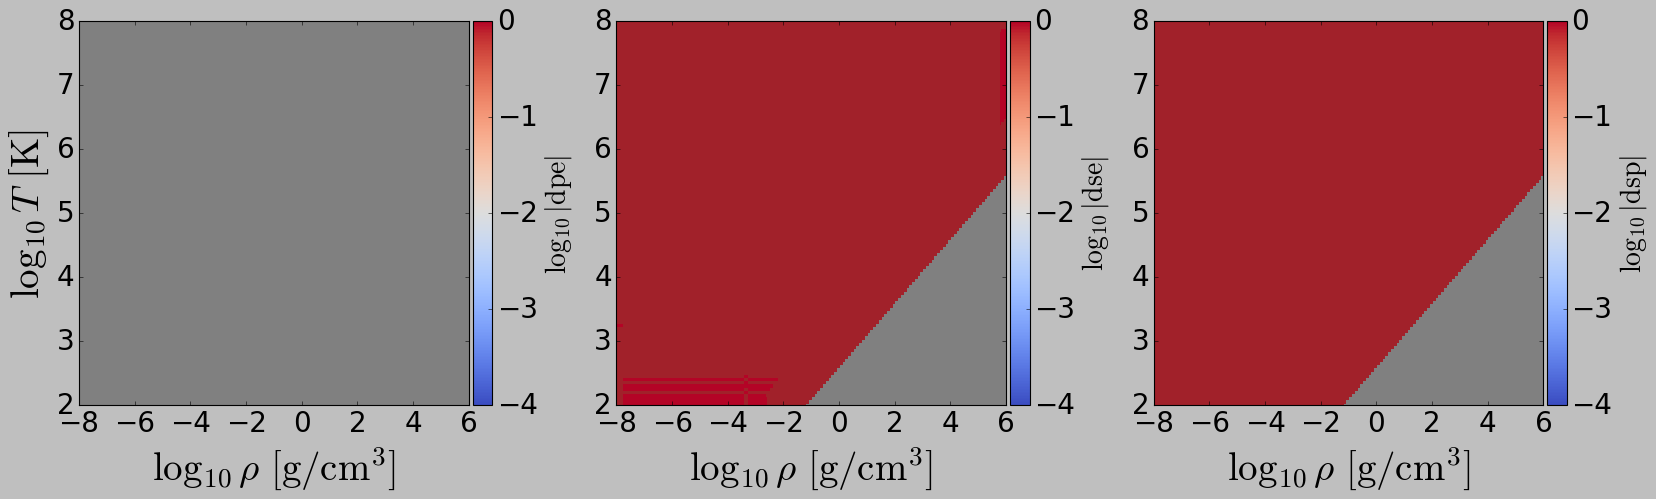

In [108]:
Z_dP_drho_T_1, Z_dS_drho_T_1, Z_dE_drho_T_1, Z_dP_dT_rho_1, Z_dS_dT_rho_1, Z_dE_dT_rho_1 =  meos.finite_difference_PSE(Z, Z_P_adj, Z_S_adj, Z_E_adj,
                                                                                                  species='Z', maskUnphysicalRegion=True, plot=True, savename=None)


Z_dpe_1, Z_dse_1, Z_dsp_1, Z_a_1, Z_b_1, Z_c_1 = meos.consistency_metrics(Z, Z_P_adj, Z_S_adj, Z_E_adj,order=6,species='Z',maskUnphysicalRegion=True,plot=False,plot_tracks=False,paperplot=True, savename=None)


# try interpolating over the bad regions

In [12]:
def interpolate_nans(grid_with_nans, log10rhogrid, log10Tgrid):
    log10rho = log10rhogrid
    log10T = log10Tgrid

    x_nonan = log10rho[~np.isnan(grid_with_nans)]
    y_nonan = log10T[~np.isnan(grid_with_nans)]
    good_grid_points = np.vstack((x_nonan.T,y_nonan.T)).T
    
    good_grid_values = grid_with_nans[~np.isnan(grid_with_nans)]

    interpolated_grid = interpolate.griddata(points=good_grid_points, values=good_grid_values, xi=(log10rho,log10T), method='linear')
    
    return interpolated_grid

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_40561/164242022.py:18: RuntimeWarning: invalid value encountered in log10
  zs=[np.log10(H_P_adj),np.log10(H_S_adj),np.log10(H_E_adj),np.log10(H_P_1),np.log10(H_S_1),np.log10(H_E_1)],


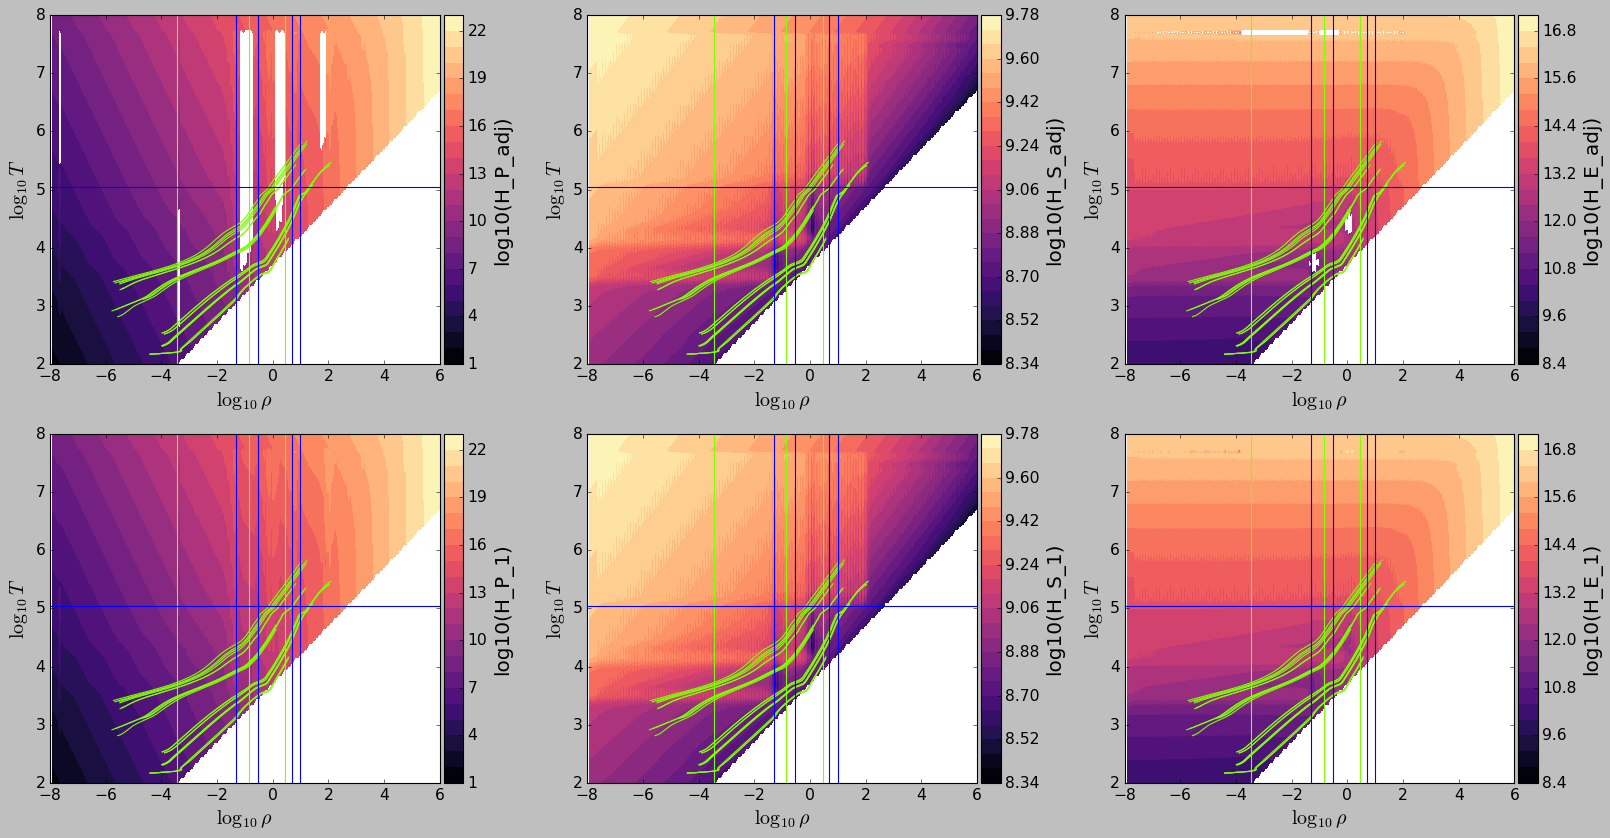

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_40561/164242022.py:46: RuntimeWarning: invalid value encountered in log10
  zs=[np.log10(He_P_adj),np.log10(He_S_adj),np.log10(He_E_adj),np.log10(He_P_1),np.log10(He_S_1),np.log10(He_E_1)],


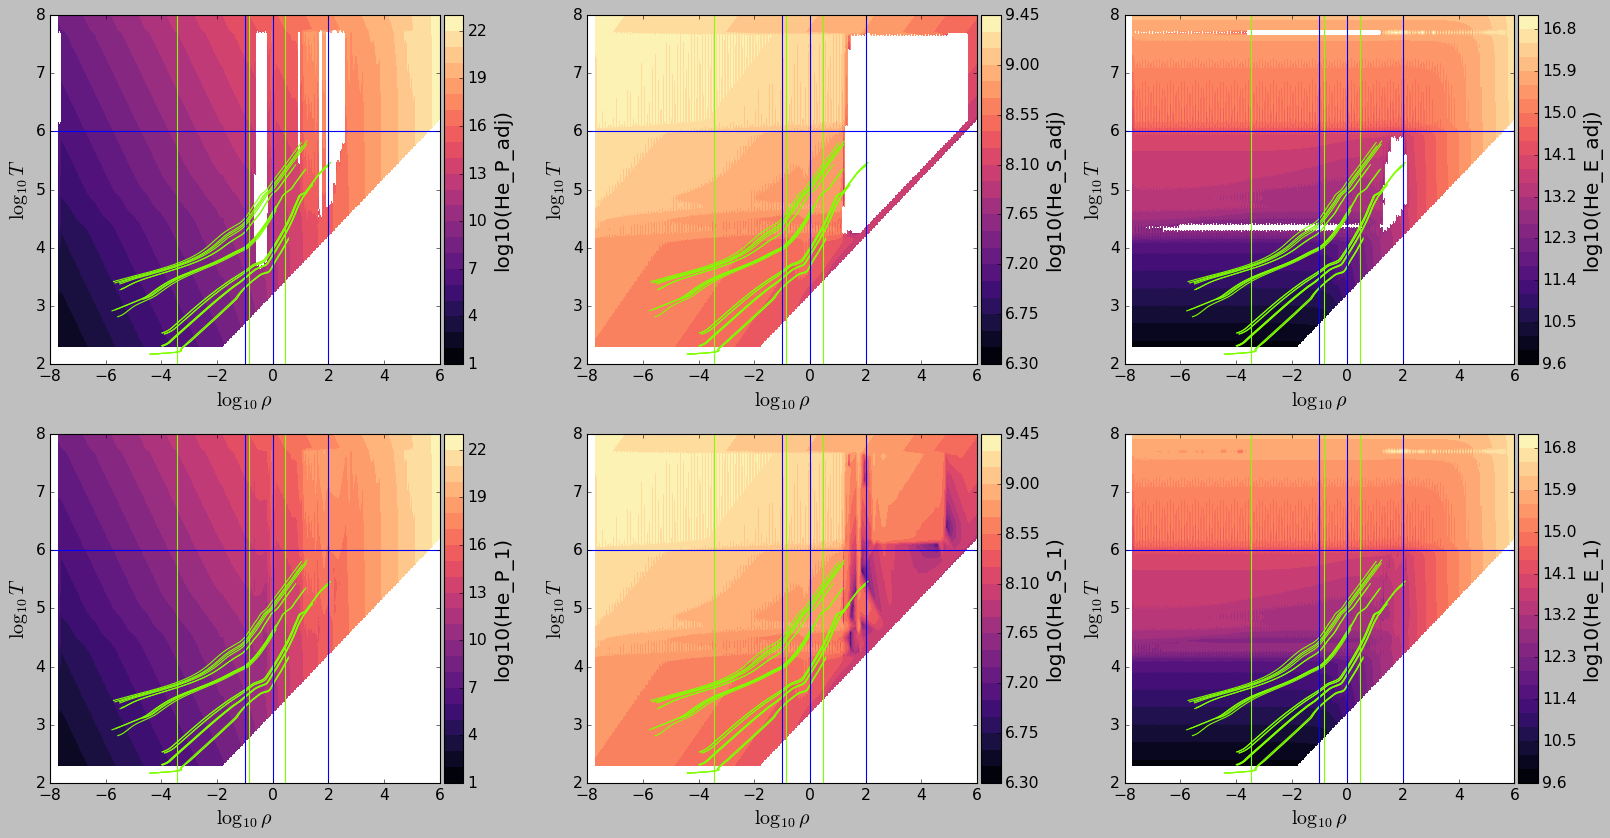

In [13]:

# look at thermo. consistency of interpolated grids
H_P_1 = copy.deepcopy(H_P_adj)
H_S_1 = copy.deepcopy(H_S_adj)
H_E_1 = copy.deepcopy(H_E_adj)

H_P_1[H_P_1 <= 0] = np.nan
H_S_1[H_S_1 <= 0] = np.nan
H_E_1[H_E_1 <= 0] = np.nan

H_P_1 = interpolate_nans(H_P_1, cms19_H.log10rhogrid, cms19_H.log10Tgrid) + H_dpe_1 - H_dpe_1
H_S_1 = interpolate_nans(H_S_1, cms19_H.log10rhogrid, cms19_H.log10Tgrid) + H_dpe_1 - H_dpe_1
H_E_1 = interpolate_nans(H_E_1, cms19_H.log10rhogrid, cms19_H.log10Tgrid) + H_dpe_1 - H_dpe_1


meos.contourf_sublots_with_colorbars(nRow=2, nCol=3, 
                                xs=cms19_H.log10rhogrid,
                                ys=cms19_H.log10Tgrid,
                                zs=[np.log10(H_P_adj),np.log10(H_S_adj),np.log10(H_E_adj),np.log10(H_P_1),np.log10(H_S_1),np.log10(H_E_1)],
                                xlims=(-8,6),
                                ylims=(2,8),
                                zlims=None,
                                levels=25,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['log10(H_P_adj)','log10(H_S_adj)','log10(H_E_adj)','log10(H_P_1)','log10(H_S_1)','log10(H_E_1)'],
                                cmap='magma', vlines=[-3.45,-0.85,0.45], hlines=None, otherlines_x=[prof['logRho'] for prof in profiles], otherlines_y=[prof['logT'] for prof in profiles], 
                                species='H', plot_interpolation_lines=True, savename=None)


He_P_1 = copy.deepcopy(He_P_adj)
He_S_1 = copy.deepcopy(He_S_adj)
He_E_1 = copy.deepcopy(He_E_adj)

He_P_1[He_P_1 <= 0] = np.nan
He_S_1[He_S_1 <= 0] = np.nan
He_E_1[He_E_1 <= 0] = np.nan

He_P_1 = interpolate_nans(He_P_1, cms19_He.log10rhogrid, cms19_He.log10Tgrid) + He_dpe_1 - He_dpe_1
He_S_1 = interpolate_nans(He_S_1, cms19_He.log10rhogrid, cms19_He.log10Tgrid) + He_dpe_1 - He_dpe_1
He_E_1 = interpolate_nans(He_E_1, cms19_He.log10rhogrid, cms19_He.log10Tgrid) + He_dpe_1 - He_dpe_1


meos.contourf_sublots_with_colorbars(nRow=2, nCol=3, 
                                xs=cms19_He.log10rhogrid,
                                ys=cms19_He.log10Tgrid,
                                zs=[np.log10(He_P_adj),np.log10(He_S_adj),np.log10(He_E_adj),np.log10(He_P_1),np.log10(He_S_1),np.log10(He_E_1)],
                                xlims=(-8,6),
                                ylims=(2,8),
                                zlims=None,
                                levels=25,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['log10(He_P_adj)','log10(He_S_adj)','log10(He_E_adj)','log10(He_P_1)','log10(He_S_1)','log10(He_E_1)'],
                                cmap='magma', vlines=[-3.45,-0.85,0.45], hlines=None, otherlines_x=[prof['logRho'] for prof in profiles], otherlines_y=[prof['logT'] for prof in profiles], 
                                species='He', plot_interpolation_lines=True, savename=None)


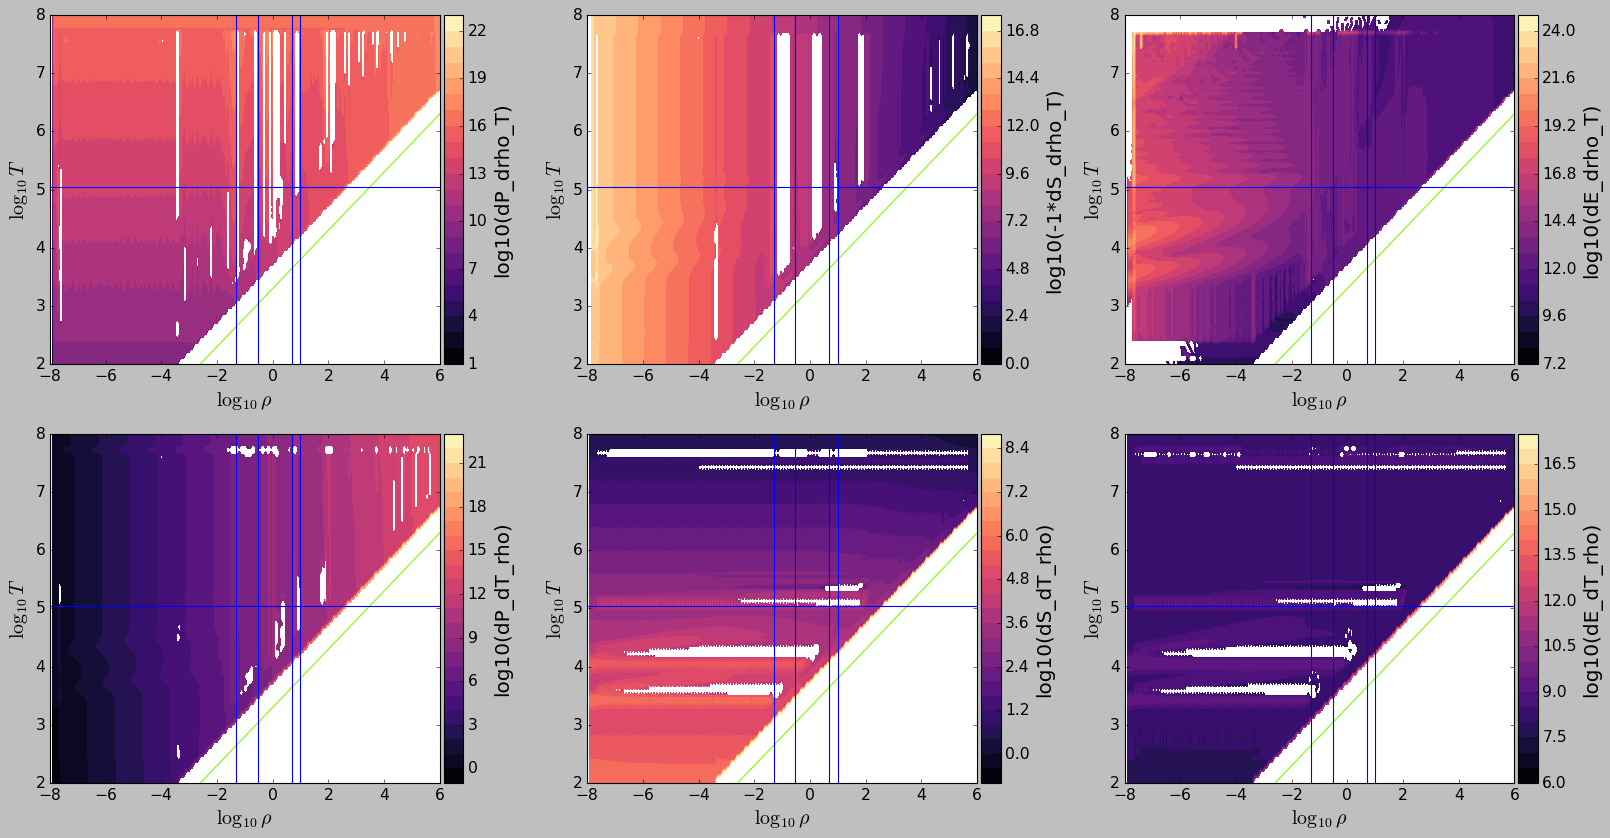

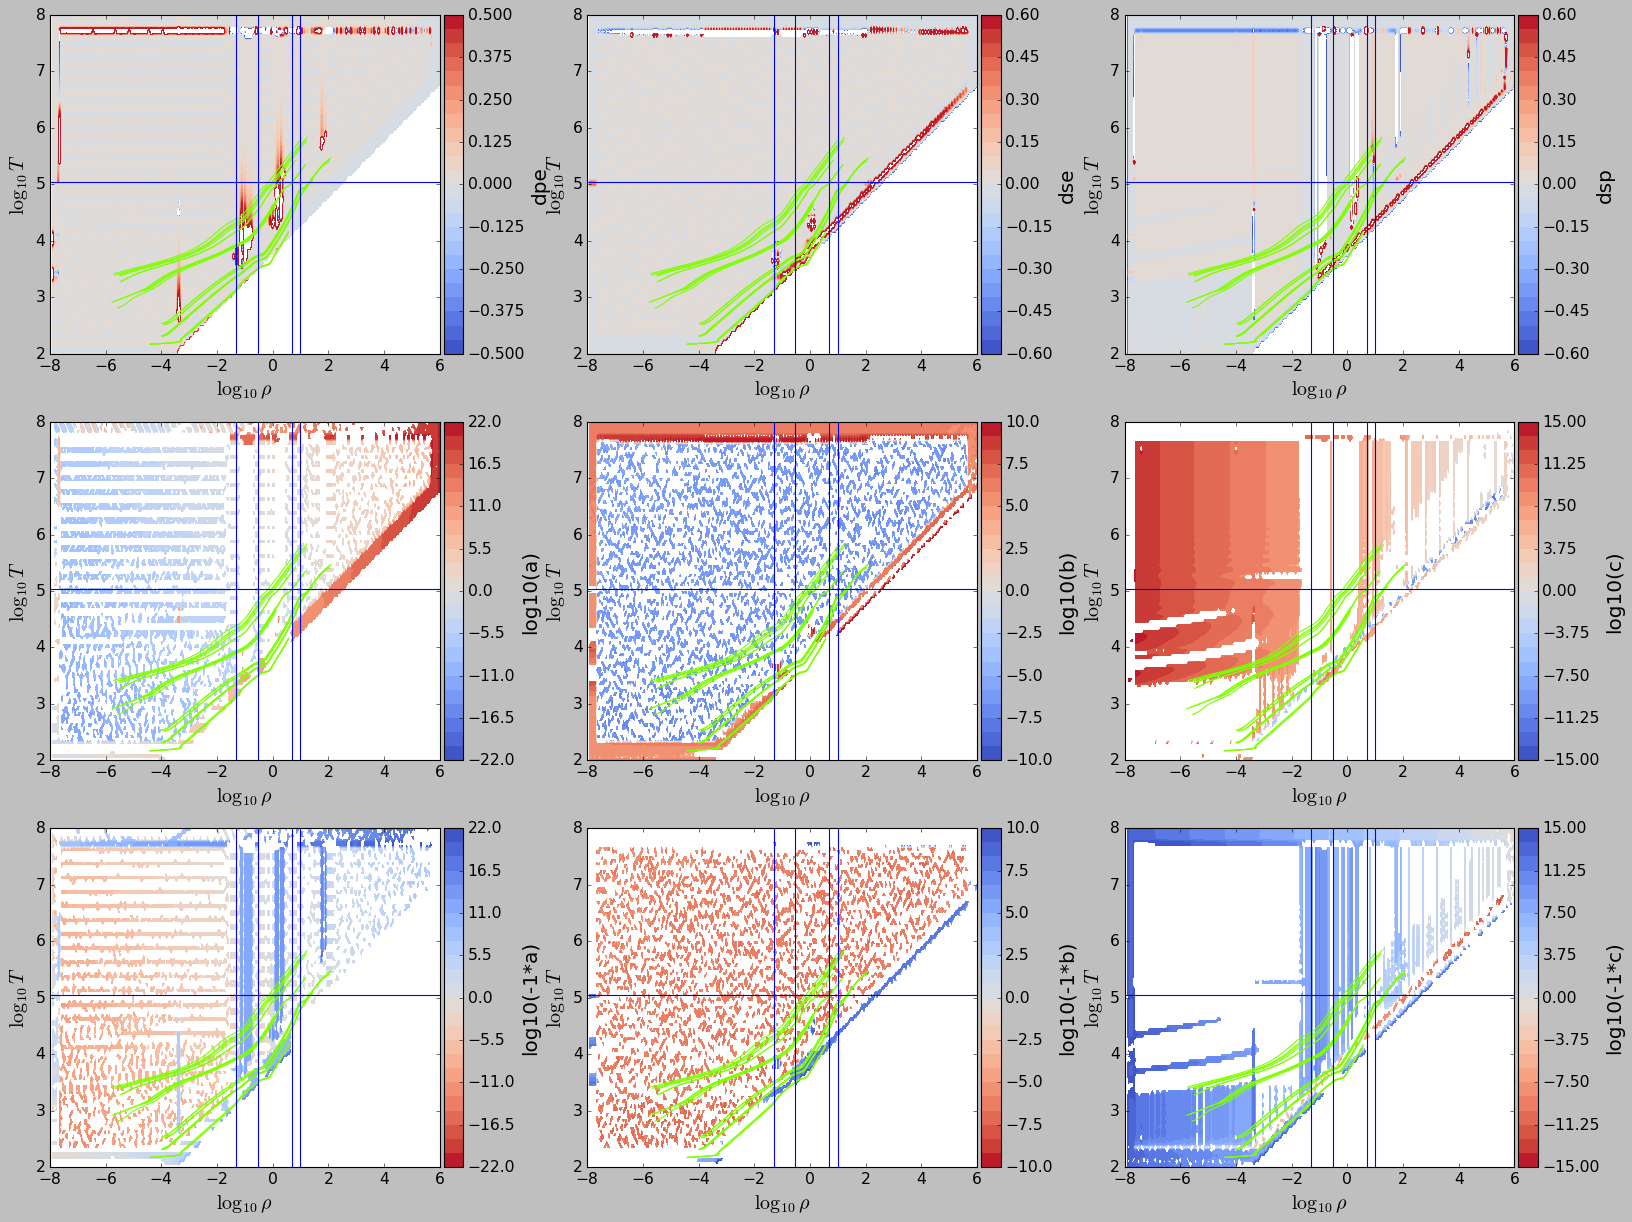

In [14]:

H_dP_drho_T_2, H_dS_drho_T_2, H_dE_drho_T_2, H_dP_dT_rho_2, H_dS_dT_rho_2, H_dE_dT_rho_2 =  meos.finite_difference(cms19_H, H_P_1, H_S_1, H_E_1,
                                                                                                  species='H', maskUnphysicalRegion=True, plot=True, savename=None)


H_dpe_2, H_dse_2, H_dsp_2, H_a_2, H_b_2, H_c_2 = meos.consistency_metrics(cms19_H, H_P_1, H_S_1, H_E_1, H_dP_drho_T_2, H_dS_drho_T_2, H_dE_drho_T_2, H_dP_dT_rho_2, H_dS_dT_rho_2, H_dE_dT_rho_2,species='H',maskUnphysicalRegion=True,plot=True, plot_tracks=True,savename=None)


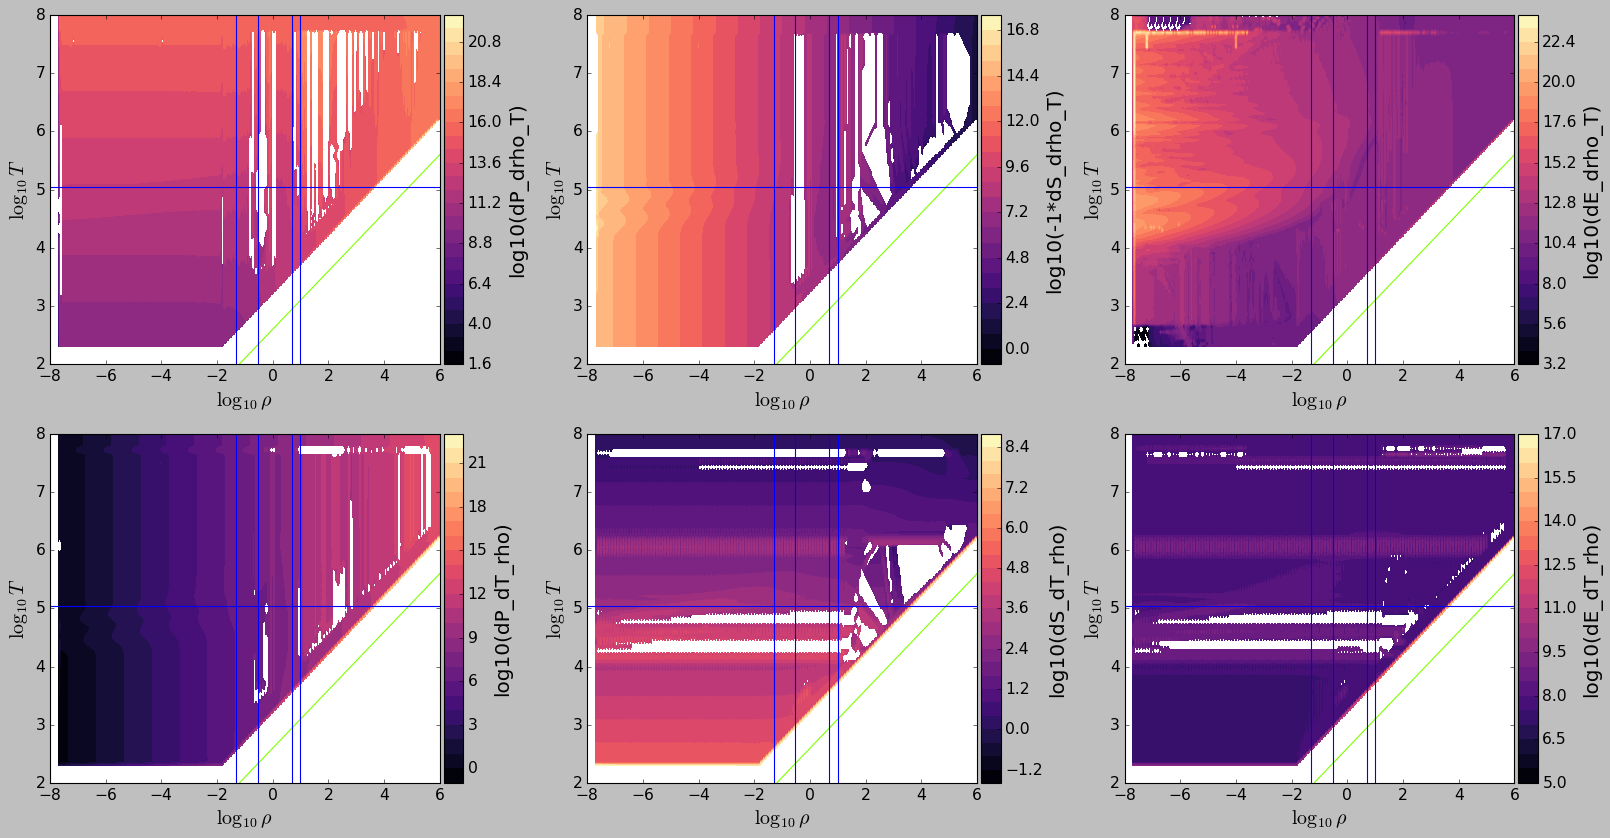

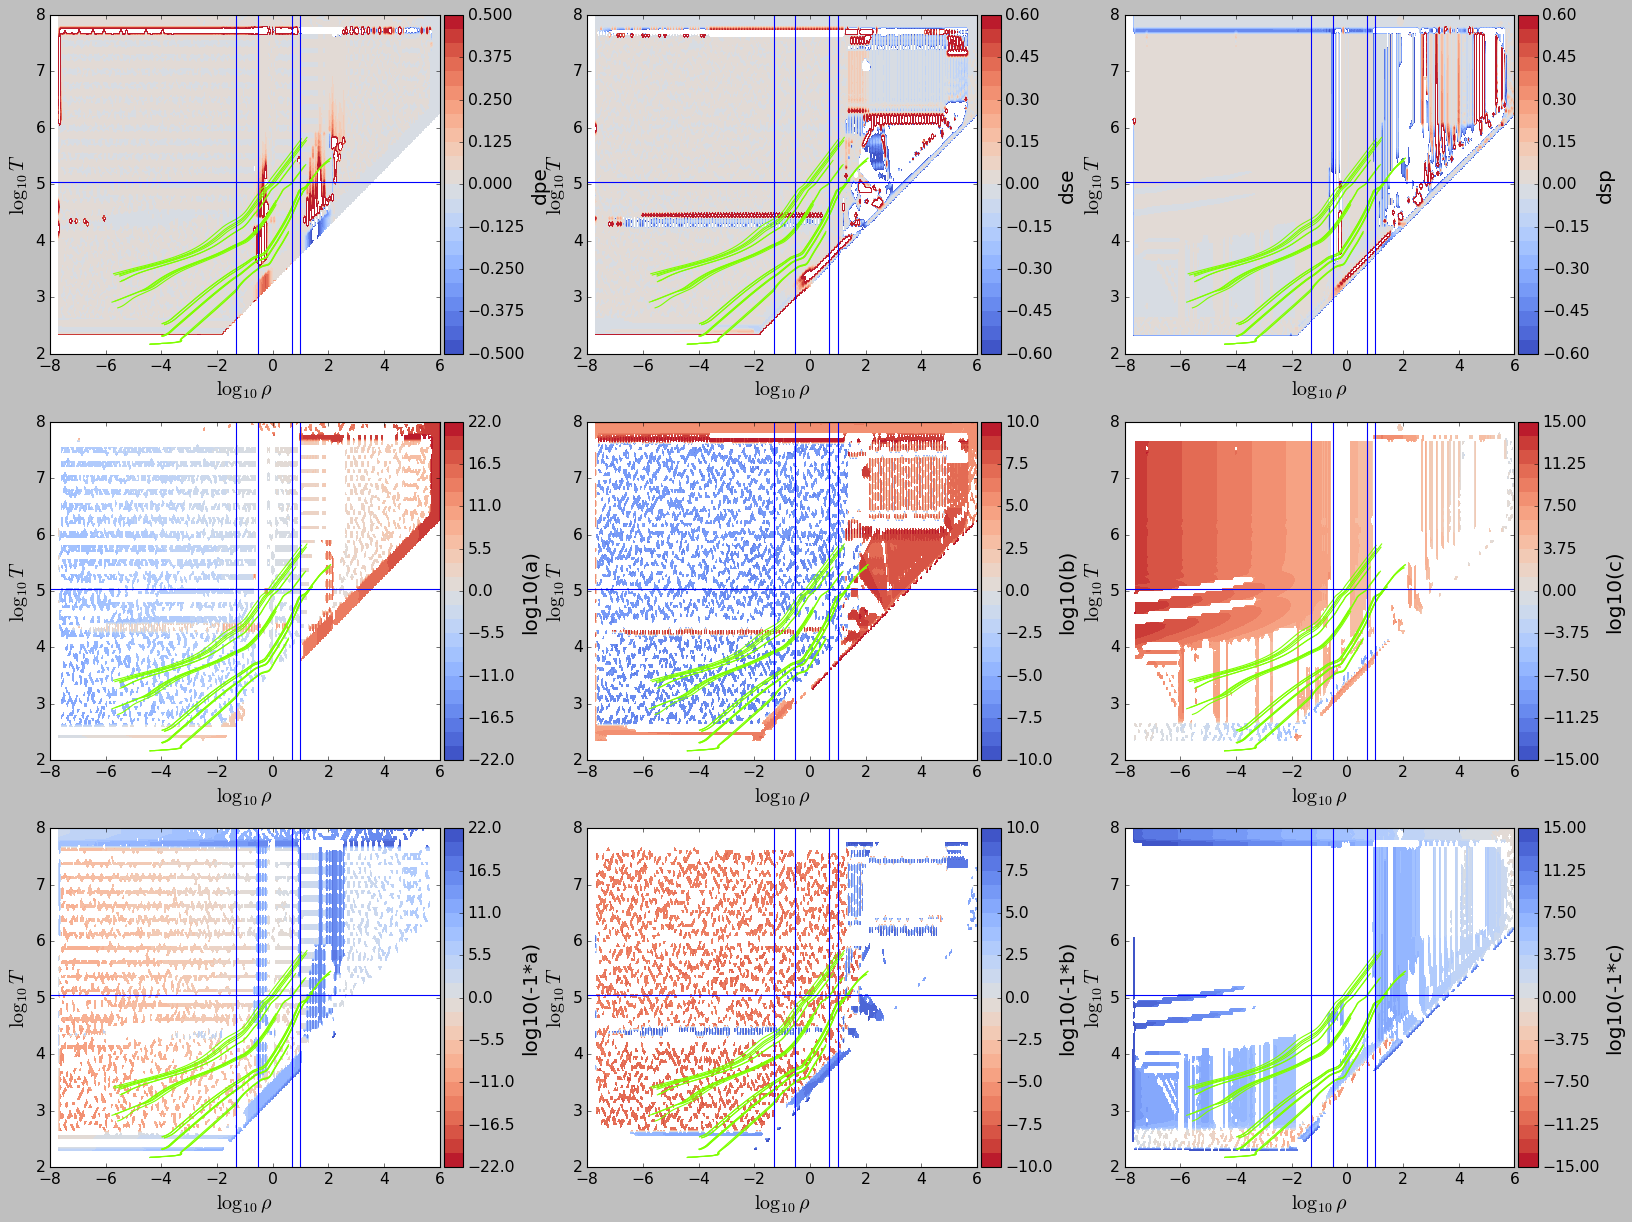

In [16]:

He_dP_drho_T_2, He_dS_drho_T_2, He_dE_drho_T_2, He_dP_dT_rho_2, He_dS_dT_rho_2, He_dE_dT_rho_2 =  meos.finite_difference(cms19_He, He_P_1, He_S_1, He_E_1,
                                                                                                  species='He', maskUnphysicalRegion=True, plot=True, savename=None)


He_dpe_2, He_dse_2, He_dsp_2, He_a_2, He_b_2, He_c_2 = meos.consistency_metrics(cms19_He, He_P_1, He_S_1, He_E_1, He_dP_drho_T_2, He_dS_drho_T_2, He_dE_drho_T_2, He_dP_dT_rho_2, He_dS_dT_rho_2, He_dE_dT_rho_2,species='He',maskUnphysicalRegion=True,plot=True,plot_tracks=True, savename=None)


# try instead adjusting the a, b, and c matrices *only* in the bad regions

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_40561/1645780948.py:1: RuntimeWarning: overflow encountered in power
  H_dpe, H_dse, H_dsp, H_a, H_b, H_c = meos.consistency_metrics(cms19_H, 10**cms19_H.log10Pgrid,10**cms19_H.log10Sgrid,10**cms19_H.log10Ugrid,H_dP_drho_T, H_dS_drho_T, H_dE_drho_T, H_dP_dT_rho, H_dS_dT_rho, H_dE_dT_rho,species='H',maskUnphysicalRegion=True,plot=False, savename=None)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_40561/1645780948.py:13: RuntimeWarning: overflow encountered in power
  H_pi_, H_sigma_, H_epsilon_ = naive_grid_update(cms19_H, 10**cms19_H.log10Pgrid,10**cms19_H.log10Sgrid,10**cms19_H.log10Ugrid,
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_40561/457977422.py:176: RuntimeWarning: divide by zero encountered in log10
  zs=[np.log10(np.abs(pi_mat_init/P_init)), np.log10(np.abs(sigma_mat_init/S_init)), np.log10(np.abs(epsilon_mat_init/E_init)),
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_40561/45

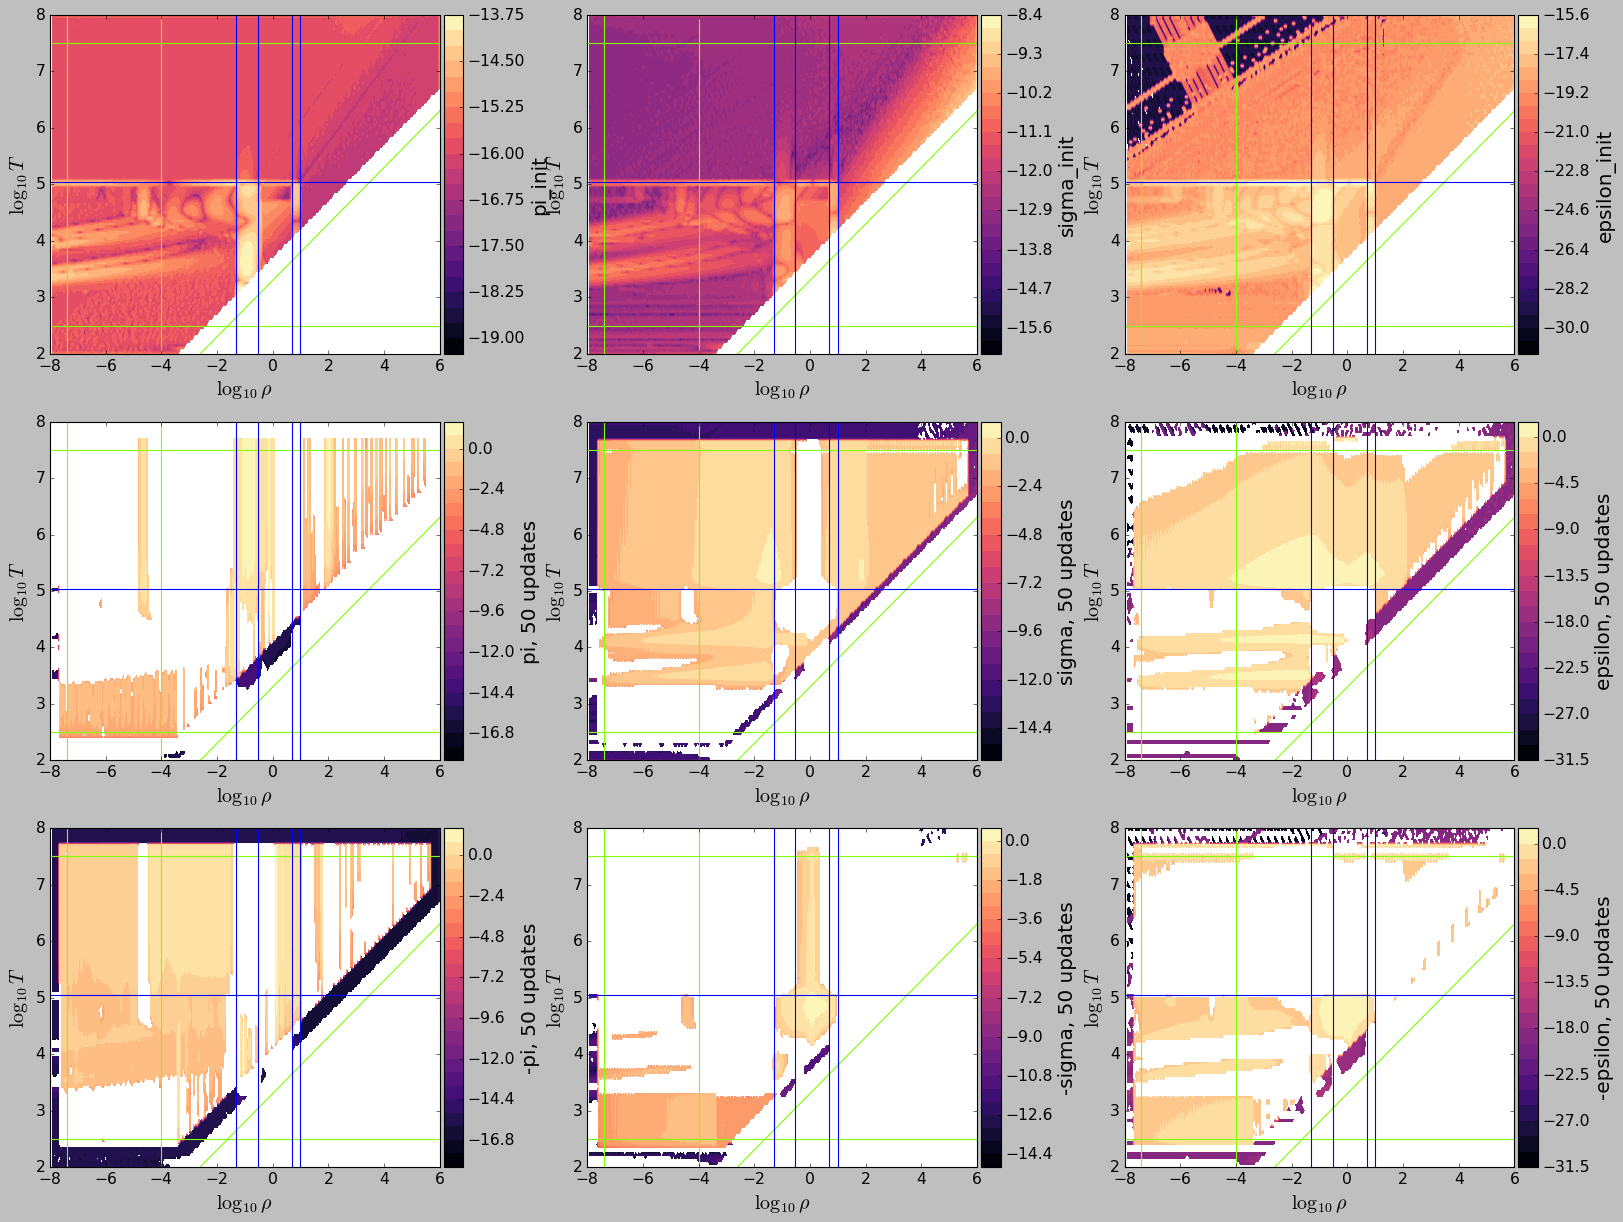

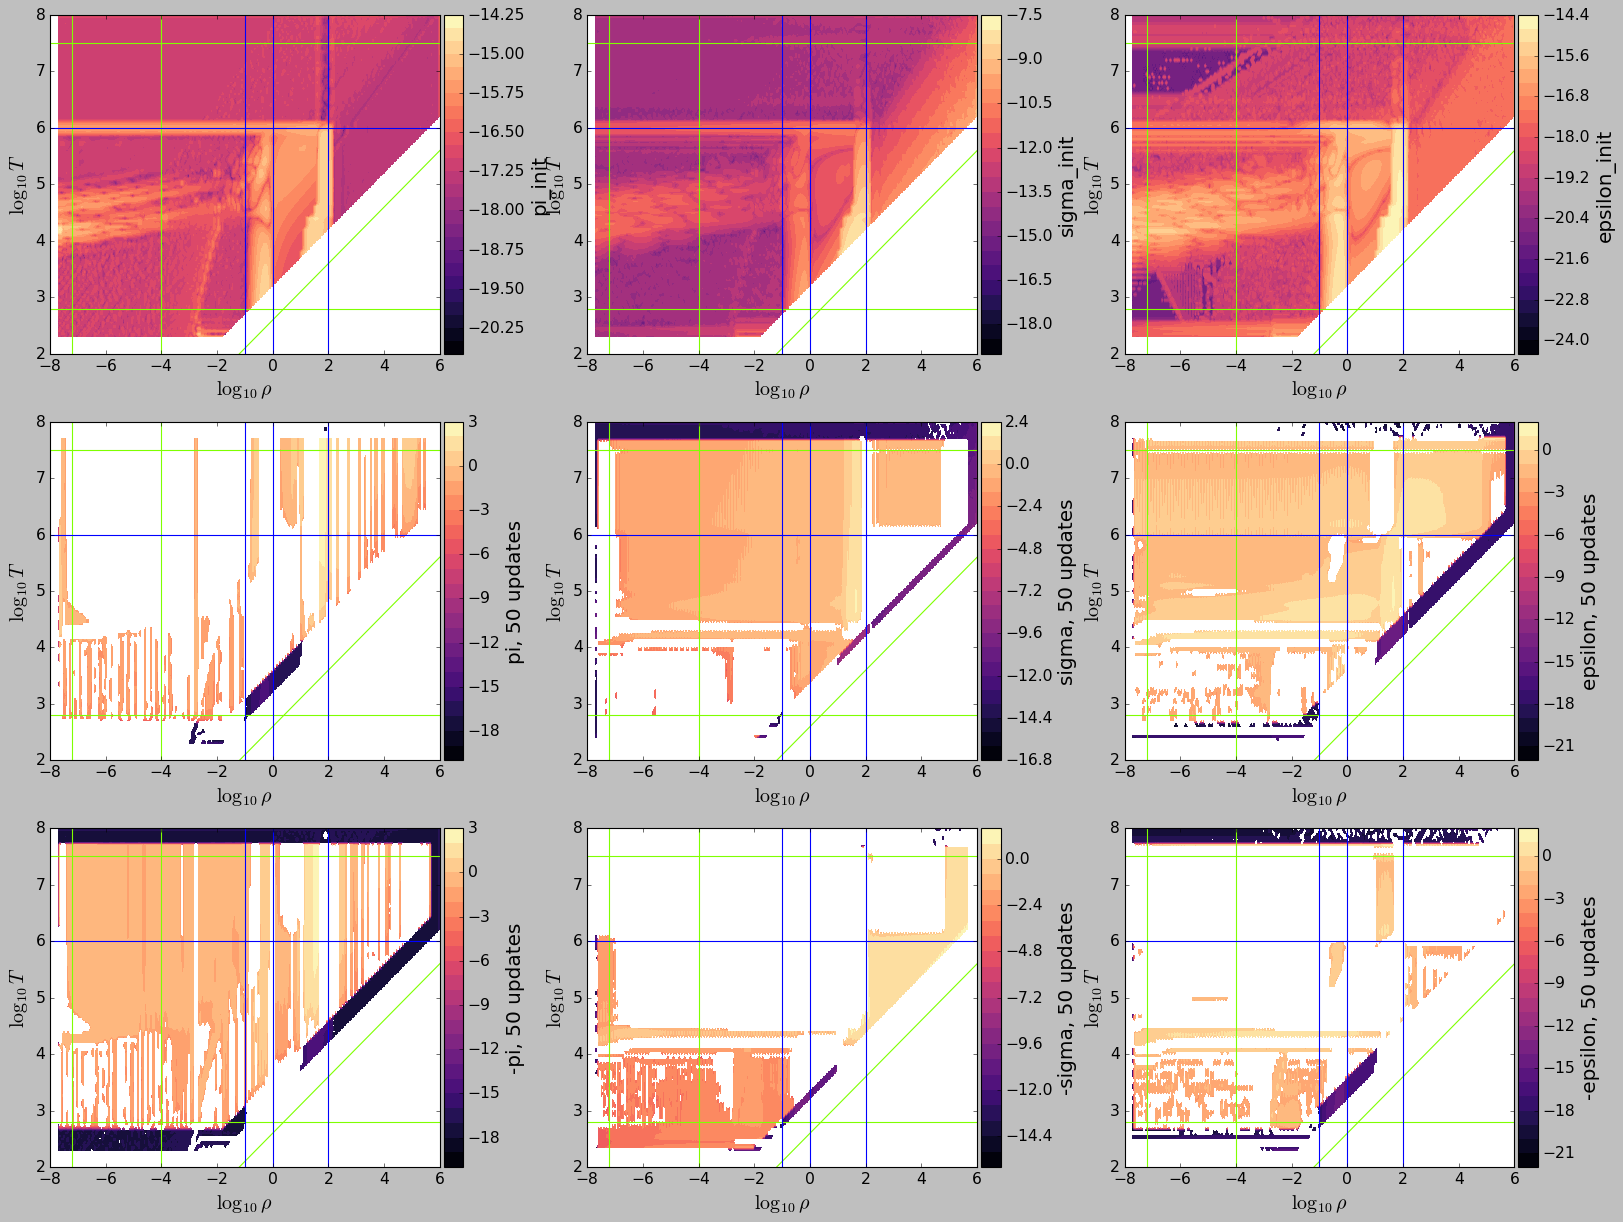

In [62]:
H_dpe, H_dse, H_dsp, H_a, H_b, H_c = meos.consistency_metrics(cms19_H, 10**cms19_H.log10Pgrid,10**cms19_H.log10Sgrid,10**cms19_H.log10Egrid,H_dP_drho_T, H_dS_drho_T, H_dE_drho_T, H_dP_dT_rho, H_dS_dT_rho, H_dE_dT_rho,species='H',maskUnphysicalRegion=True,plot=False, savename=None)

H_a_adj = copy.deepcopy(H_a)
H_b_adj = copy.deepcopy(H_b)
H_c_adj = copy.deepcopy(H_c)

H_bad_mask = (H_P_adj <= 0) | (H_S_adj <= 0) | (H_E_adj <= 0)

#H_a_adj *= 0.1
H_b_adj *= 0.1
#H_c_adj *= 0.1

H_pi_, H_sigma_, H_epsilon_ = naive_grid_update(cms19_H, 10**cms19_H.log10Pgrid,10**cms19_H.log10Sgrid,10**cms19_H.log10Egrid, 
                                          species='H', ic='oom',nUpdates=50, plot=True, a=H_a_adj, b=H_b_adj, c=H_c_adj)



He_dpe, He_dse, He_dsp, He_a, He_b, He_c = meos.consistency_metrics(cms19_He, 10**new_P,10**new_S,10**new_E,He_dP_drho_T, He_dS_drho_T, He_dE_drho_T, He_dP_dT_rho, He_dS_dT_rho, He_dE_dT_rho,species='He',maskUnphysicalRegion=True,plot=False, savename=None)

He_a_adj = copy.deepcopy(He_a)
He_b_adj = copy.deepcopy(He_b)
He_c_adj = copy.deepcopy(He_c)

He_bad_mask = (He_P_adj <= 0) | (He_S_adj <= 0) | (He_E_adj <= 0)

#He_a_adj *= 0.1
He_b_adj *= 0.1
#He_c_adj *= 0.1

He_pi_, He_sigma_, He_epsilon_ = naive_grid_update(cms19_He, 10**new_P,10**new_S,10**new_E, 
                                          species='He', ic='oom',nUpdates=50, plot=True, a=He_a_adj, b=He_b_adj, c=He_c_adj)

In [63]:
H_P_adj = 10**cms19_H.log10Pgrid + H_pi_
H_S_adj = 10**cms19_H.log10Sgrid + H_sigma_
H_E_adj = 10**cms19_H.log10Egrid + H_epsilon_

He_P_adj = 10**new_P + He_pi_
He_S_adj = 10**new_S + He_sigma_
He_E_adj = 10**new_E + He_epsilon_

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_40561/2405727242.py:2: RuntimeWarning: overflow encountered in power
  H_S_adj = 10**cms19_H.log10Sgrid + H_sigma_
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_40561/2405727242.py:3: RuntimeWarning: overflow encountered in power
  H_E_adj = 10**cms19_H.log10Ugrid + H_epsilon_


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_40561/1328871254.py:4: RuntimeWarning: invalid value encountered in log10
  zs=[np.log10(H_P_adj),np.log10(H_S_adj),np.log10(H_E_adj)],


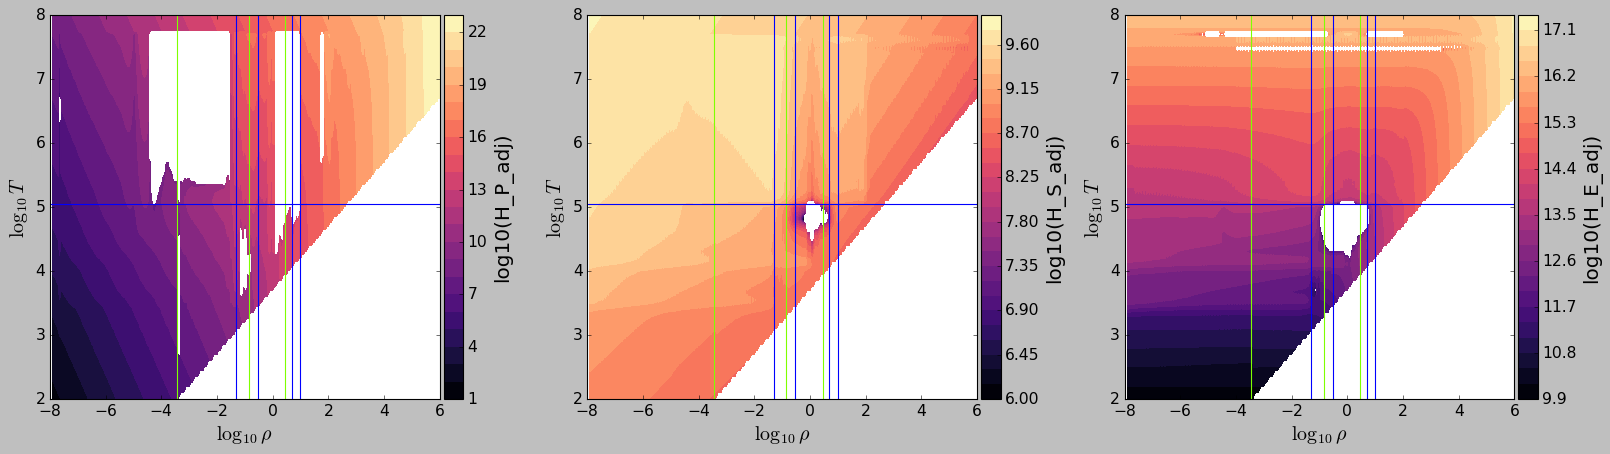

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_40561/1328871254.py:19: RuntimeWarning: invalid value encountered in log10
  zs=[np.log10(He_P_adj),np.log10(He_S_adj),np.log10(He_E_adj)],


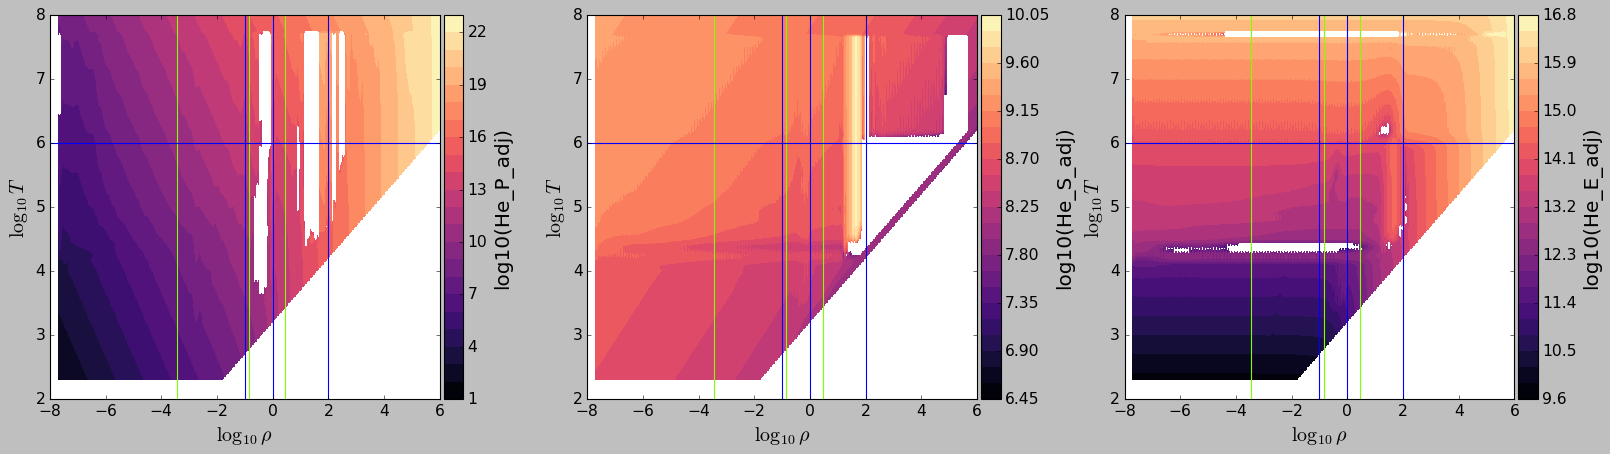

In [64]:
meos.contourf_sublots_with_colorbars(nRow=1, nCol=3, 
                                xs=cms19_H.log10rhogrid,
                                ys=cms19_H.log10Tgrid,
                                zs=[np.log10(H_P_adj),np.log10(H_S_adj),np.log10(H_E_adj)],
                                xlims=(-8,6),
                                ylims=(2,8),
                                zlims=None,
                                levels=25,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['log10(H_P_adj)','log10(H_S_adj)','log10(H_E_adj)'],
                                cmap='magma', vlines=[-3.45,-0.85,0.45], hlines=None, otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=True, savename=None)


meos.contourf_sublots_with_colorbars(nRow=1, nCol=3, 
                                xs=cms19_He.log10rhogrid,
                                ys=cms19_He.log10Tgrid,
                                zs=[np.log10(He_P_adj),np.log10(He_S_adj),np.log10(He_E_adj)],
                                xlims=(-8,6),
                                ylims=(2,8),
                                zlims=None,
                                levels=25,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['log10(He_P_adj)','log10(He_S_adj)','log10(He_E_adj)'],
                                cmap='magma', vlines=[-3.45,-0.85,0.45], hlines=None, otherlines_x=None, otherlines_y=None, 
                                species='He', plot_interpolation_lines=True, savename=None)


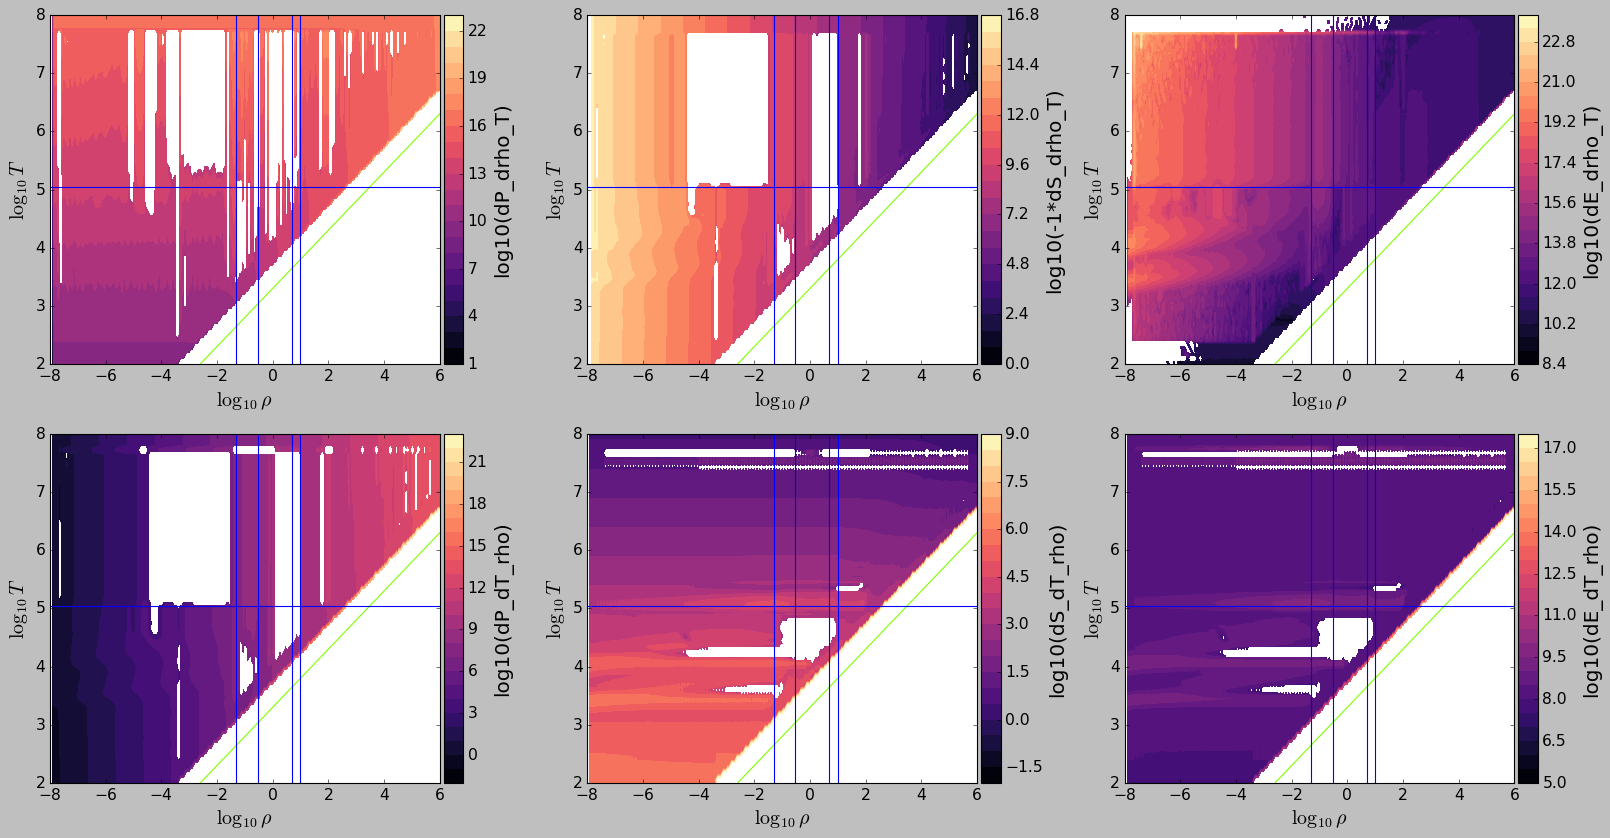

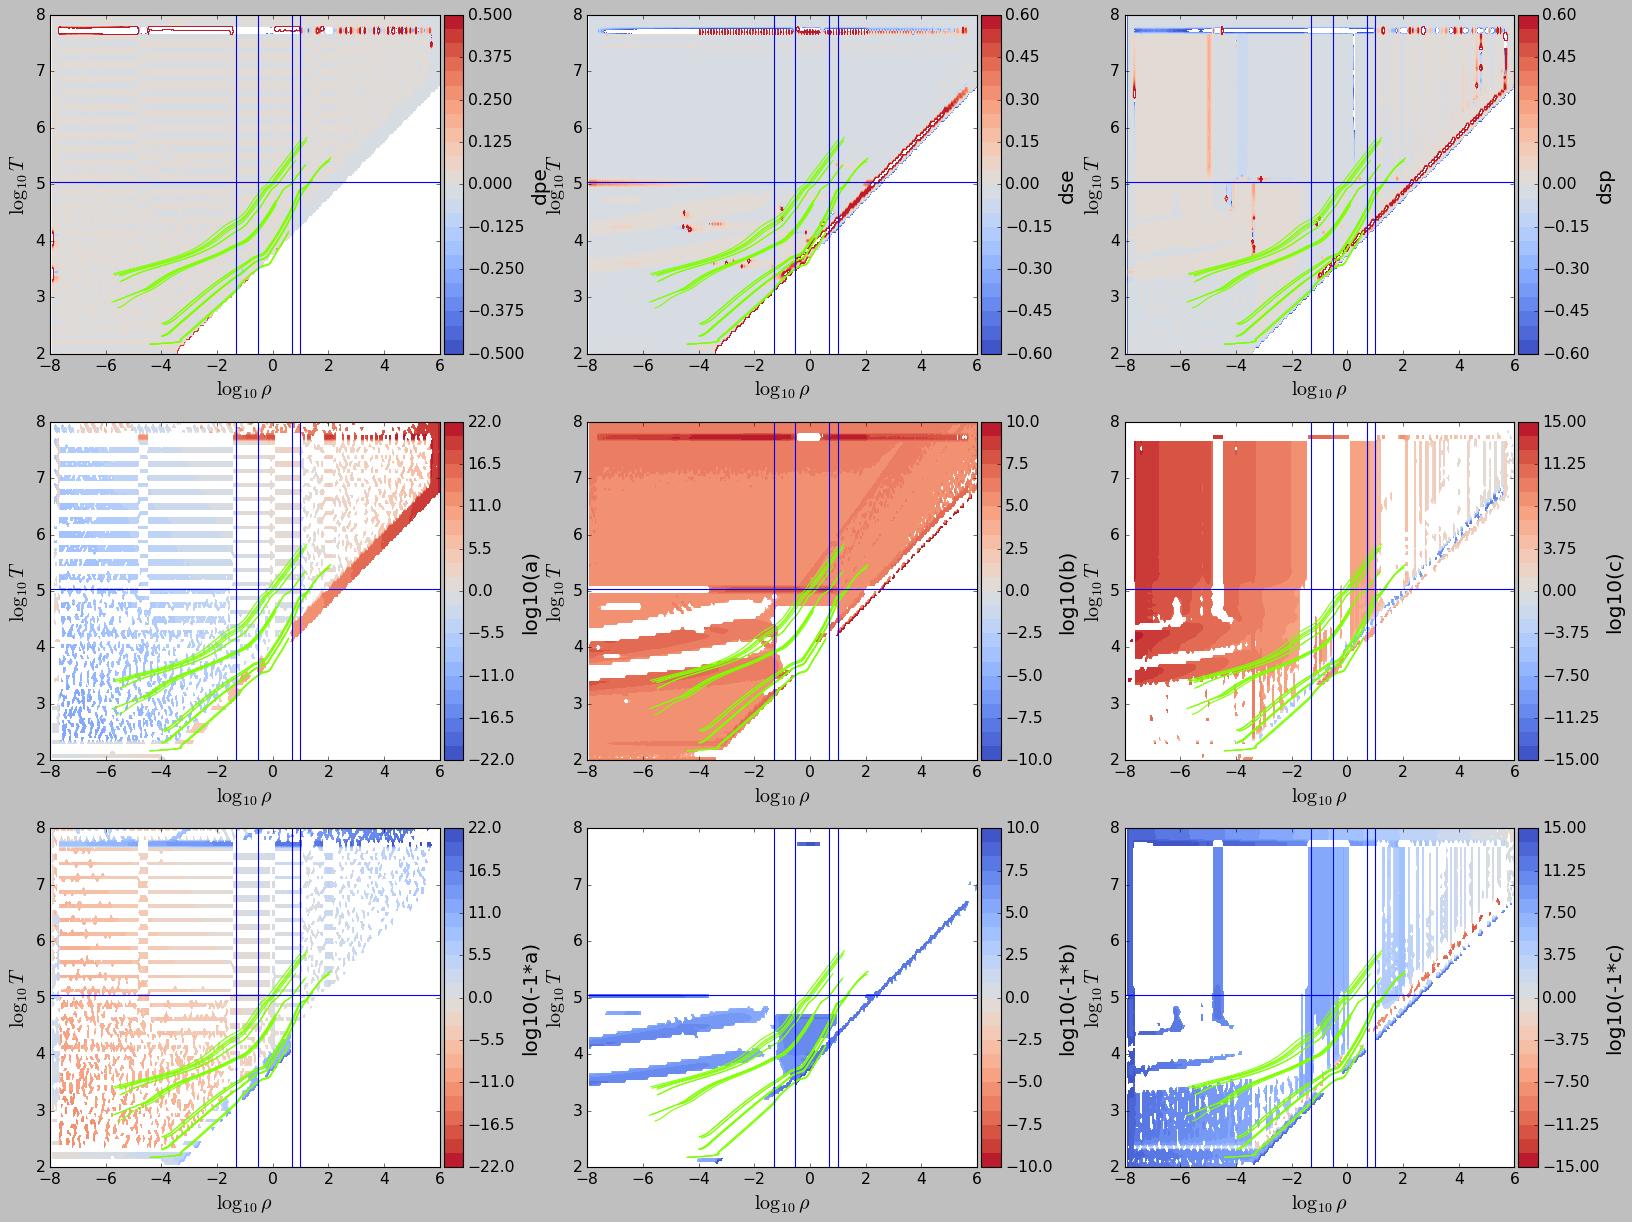

In [65]:
H_dP_drho_T_1, H_dS_drho_T_1, H_dE_drho_T_1, H_dP_dT_rho_1, H_dS_dT_rho_1, H_dE_dT_rho_1 =  meos.finite_difference(cms19_H, H_P_adj, H_S_adj, H_E_adj,
                                                                                                  species='H', maskUnphysicalRegion=True, plot=True, savename=None)


H_dpe_1, H_dse_1, H_dsp_1, H_a_1, H_b_1, H_c_1 = meos.consistency_metrics(cms19_H, H_P_adj, H_S_adj, H_E_adj, H_dP_drho_T_1, H_dS_drho_T_1, H_dE_drho_T_1, H_dP_dT_rho_1, H_dS_dT_rho_1, H_dE_dT_rho_1,species='H',maskUnphysicalRegion=True,plot=True,plot_tracks=True, savename=None)


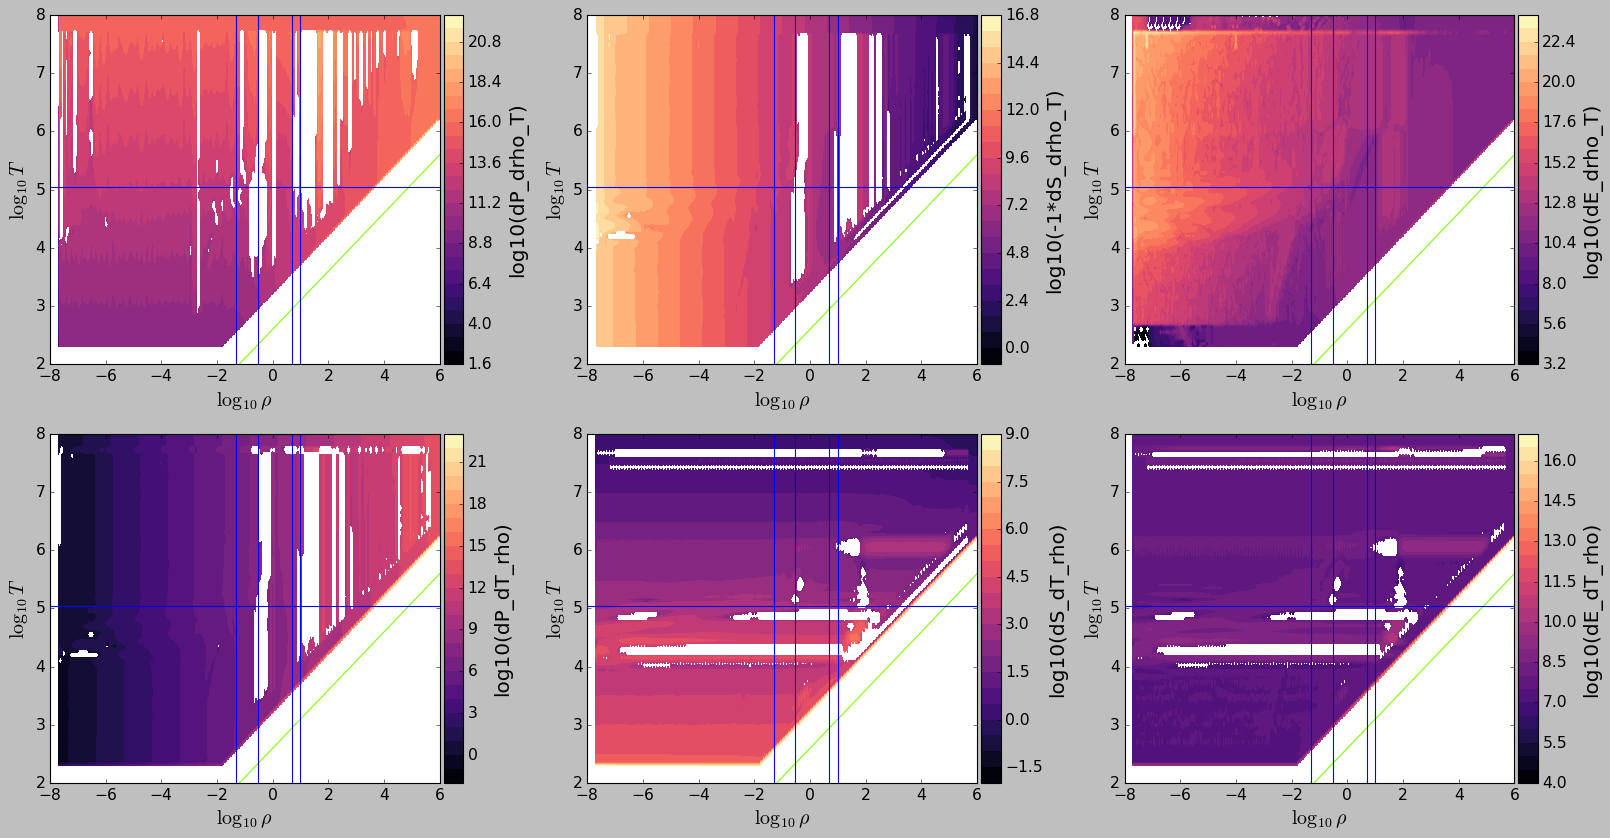

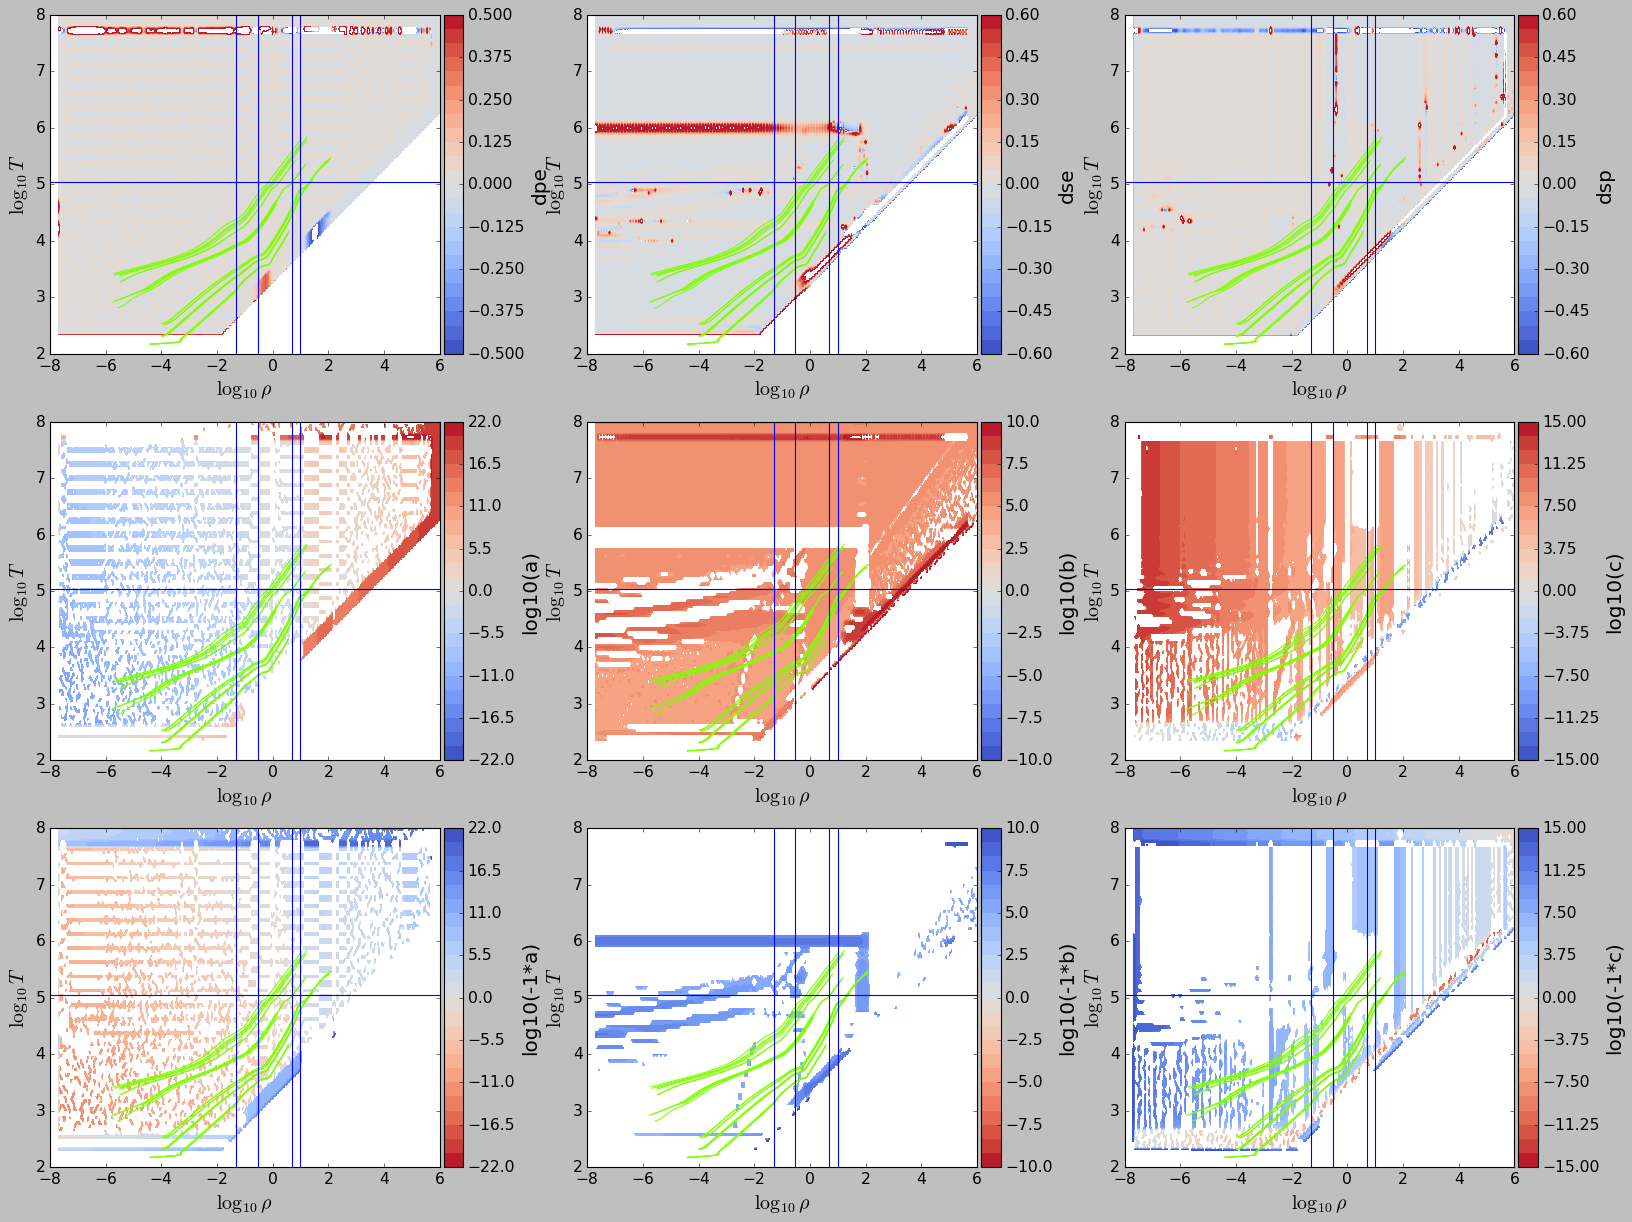

In [66]:
He_dP_drho_T_1, He_dS_drho_T_1, He_dE_drho_T_1, He_dP_dT_rho_1, He_dS_dT_rho_1, He_dE_dT_rho_1 =  meos.finite_difference(cms19_He, He_P_adj, He_S_adj, He_E_adj,
                                                                                                  species='He', maskUnphysicalRegion=True, plot=True, savename=None)


He_dpe_1, He_dse_1, He_dsp_1, He_a_1, He_b_1, He_c_1 = meos.consistency_metrics(cms19_He, He_P_adj, He_S_adj, He_E_adj, He_dP_drho_T_1, He_dS_drho_T_1, He_dE_drho_T_1, He_dP_dT_rho_1, He_dS_dT_rho_1, He_dE_dT_rho_1,species='He',maskUnphysicalRegion=True,plot=True, plot_tracks=True,savename=None)
